<a href="https://colab.research.google.com/github/haskinse/bee2041_empirical_project/blob/main/source_code/04_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive # connect to google drive
drive.mount("/content/drive")

project_path = "/content/drive/MyDrive/bee2041_empirical_project" # define project path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
era_colours = { # a dictionary to match era to consistant colours
  "Taylor Swift": "#a4caa5", # green / teal
  "Fearless": "#f0c080", # yellow / gold
  "Speak Now": "#c7a8ca", # purple
  "Red": "#7a2e3a", # red
  "1989": "#b5e5f9", # light blue
  "Reputation": "#000000", # black
  "Lover": "#f6b0cc", # pink
  "Folklore": "#cdc9c0", # grey
  "Evermore": "#c5ac90", # brown
  "Midnights": "#1b4b7d", # navy
  "TTPD": "#e3dcdc", # white
  "The Life of a Showgirl": "#e15921" # orange
}

In [ ]:
import matplotlib.pyplot as plt # library for data visualisation
import pandas as pd # library for data manipulation and tables
import seaborn as sns # used for statistical data visualisation
import sqlite3 # ibrary used to create and interact with SQLite databases

In [ ]:
def plot_album_chart_performance(chart_peak, country, figure_name): # plot album chart performance for a given country

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve album names, eras and chart peak metric
  chart_performance = pd.read_sql(f"""
  SELECT album_id, album_name, era, {chart_peak} AS chart_peak
  FROM albums
  """, conn)

  # exclude Taylor’s Version albums to avoid doubling of eras
  chart_performance = chart_performance[~chart_performance["album_name"].str.contains("Taylor's Version", regex = False)]

  # replace long names with abbreviations for easier visualisation
  chart_performance["era"] = chart_performance["era"].replace({"The Tortured Poets Department": "TTPD"})
  chart_performance["era"] = chart_performance["era"].replace({"The Life of a Showgirl": "Life of a Showgirl"})

  colours = chart_performance["era"].astype(str).map(era_colours).fillna("#cccccc") # assign consistent colours to each era

  sns.reset_defaults() # ensures that style is set to default

  plt.figure(figsize = (8, 6)) # set figure size

  plt.plot(chart_performance["era"], chart_performance["chart_peak"], color = "grey", linestyle = "--") # plot a trend line across eras

  plt.scatter(chart_performance["era"], chart_performance["chart_peak"], color = colours) # add scatter points coloured by era

  plt.xticks(rotation = 45, ha = "right") # rotate labels for readability

  # label the axes and title
  plt.xlabel("Era")
  plt.ylabel("Chart Peak")
  plt.title(f"{country} Chart Peaks by Era")

  lowest_peak = chart_performance["chart_peak"].max() # find the worst chart position

  if lowest_peak < 10:
    offset = 0.1 # use small label offset when values are across a small scale

  else:
    offset = 2 # use larger offset when values are more spread out

  # annotate each point with its chart peak value
  for i, row in chart_performance.iterrows():
    plt.text(row["era"], row["chart_peak"] - offset, str(row["chart_peak"]), fontsize = 9, ha = "center")

  # remove unnecessary borders for cleaner visualisation
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.gca().invert_yaxis() # swap the axis so rank 1 is at the top

  plt.savefig(f"{project_path}/output/figures/chart_performance/{figure_name}.png", dpi = 300, bbox_inches = "tight") # saves figure to drive

  plt.tight_layout()
  plt.show() # show the final chart

  conn.close() # close database connection

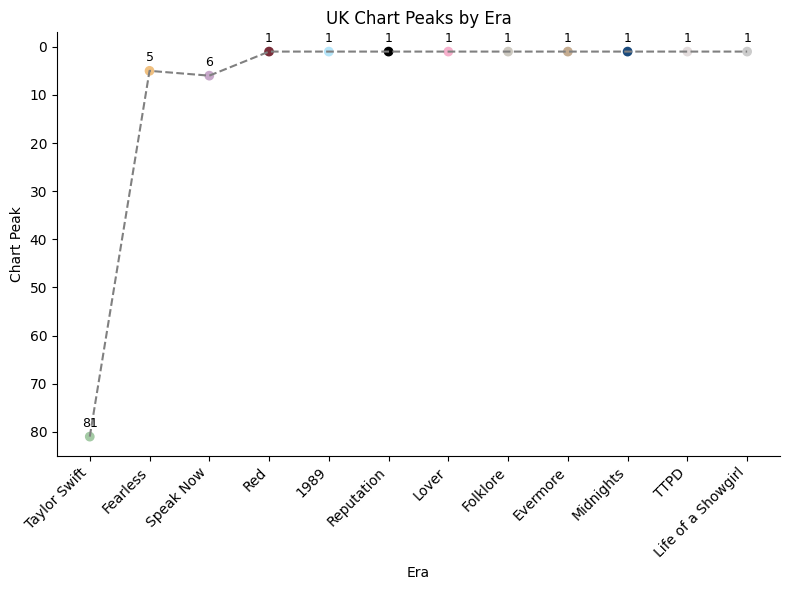

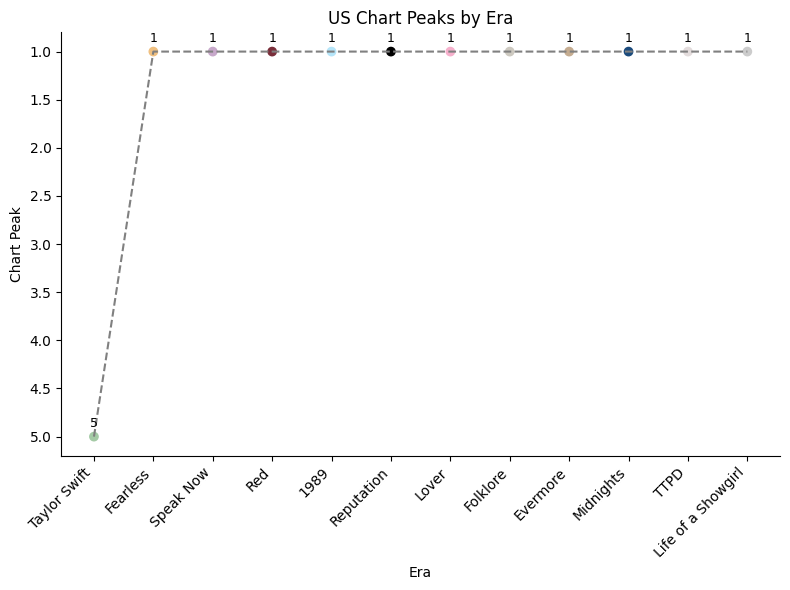

In [ ]:
plot_album_chart_performance("uk_peak", "UK", "uk_chart_performance") # plot the chart performance of Taylor Swift eras in the UK

plot_album_chart_performance("us_peak", "US", "us_chart_performance") # plot the chart performance of Taylor Swift eras in the US

In [ ]:
import matplotlib.colors as mcolors # for manipulating colours

In [ ]:
def lighten_colour(colour, amount): # function to lighten colours
  c = mcolors.to_rgb(colour) # converts colour to rgb
  return tuple(1 - (1 - x) * (1 - amount) for x in c) # shifts it towards white

In [ ]:
# list of eras in order
era_order = ["Taylor Swift", "Fearless", "Speak Now", "Red", "1989", "Reputation", "Lover", "Folklore", "Evermore", "Midnights", "TTPD", "The Life of a Showgirl"]

In [ ]:
def plot_album_commercial_success(metric_a, metric_b, metric_name, figure_name): # analyse and visualise era success using metrics

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve album data and compute combined success metric
  popularity_by_metric = pd.read_sql(f"""
  SELECT album_id, album_name, {metric_a} + {metric_b} AS total_metric
  FROM albums
  """, conn)

  popularity_by_metric["total_metric"] = popularity_by_metric["total_metric"] / 1000000 # scale values to millions for clearer visualisation

  # group Taylor’s Version albums with their original era
  popularity_by_metric["era"] = popularity_by_metric["album_name"].str.replace(r" \(Taylor's Version\)", "", regex = True)

  # create indicator for Taylor’s Version vs original releases
  popularity_by_metric["is_tv"] = popularity_by_metric["album_name"].str.contains("Taylor's Version", regex = False)

  popularity_by_metric["era"] = popularity_by_metric["era"].replace({"The Tortured Poets Department": "TTPD"}) # replace Tortured Poets with TTPD for readability

  # reshape data to separate original and Taylor’s Version contributions per era
  popularity_by_metric = (popularity_by_metric.pivot_table(index = "era", columns = "is_tv", values = "total_metric", aggfunc = "sum", fill_value = 0).rename(columns = {False: "original", True: "tv"}).reset_index())

  # enforce chronological ordering of eras
  popularity_by_metric["era"] = pd.Categorical(popularity_by_metric["era"], categories = era_order, ordered = True)

  popularity_by_metric = popularity_by_metric.sort_values("era") # sort data according to defined era order

  # assign colours AFTER reshaping so lengths match
  base_colours = popularity_by_metric["era"].astype(str).map(era_colours).fillna("#cccccc") # assign consistent colours to each era
  tv_colours = [lighten_colour(c, 0.5) for c in base_colours] # create lighter shades for Taylor’s Version

  sns.reset_defaults() # ensures that the sns style starts at default
  sns.set_style("whitegrid") # adds a grid in the background of the figure

  plt.figure(figsize = (8, 6)) # create a stacked bar chart

  # plot original album performance
  plt.bar(popularity_by_metric["era"], popularity_by_metric["original"], label = "Original", color = base_colours)

  # add stacked Taylor’s Version contributions
  plt.bar(popularity_by_metric["era"], popularity_by_metric["tv"], bottom = popularity_by_metric["original"], label = "Taylor's Version", color = tv_colours)

  plt.xticks(rotation = 45, ha = "right") # rotate labels for readability

  # label chart axes and title
  plt.xlabel("Era")
  plt.ylabel(f"Total {metric_name} (Millions)")
  plt.title(f"Most Successful Taylor Swift Albums (by US & UK {metric_name})")

  plt.legend() # display legend for original vs Taylor’s Version

  # remove unnecessary borders
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.savefig(f"{project_path}/output/figures/commercial_success/{figure_name}_bar.png", dpi = 300, bbox_inches = "tight") # saves figure to drive

  plt.tight_layout()
  plt.show() # display final chart

  conn.close() # close database connection

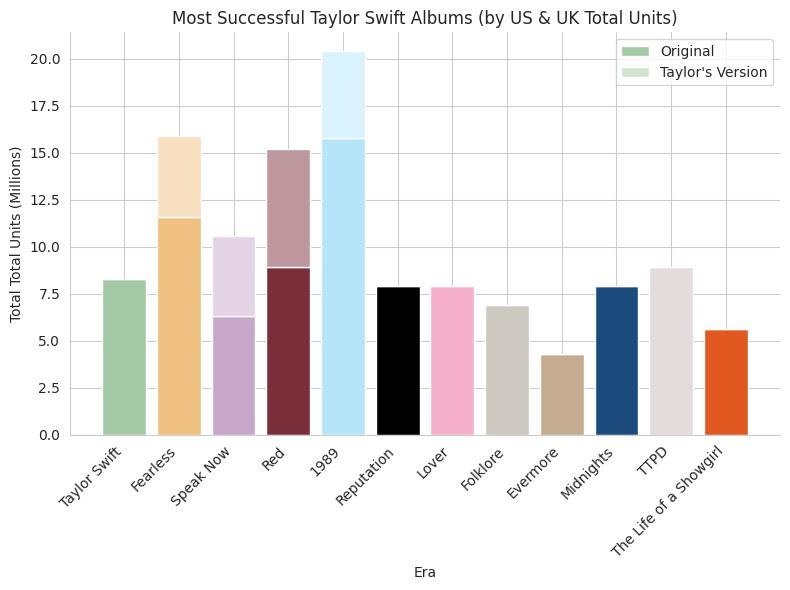

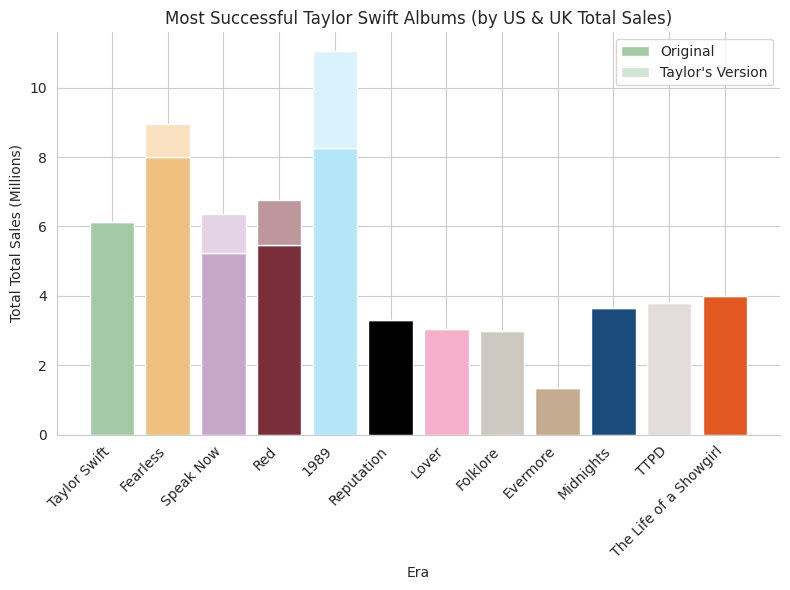

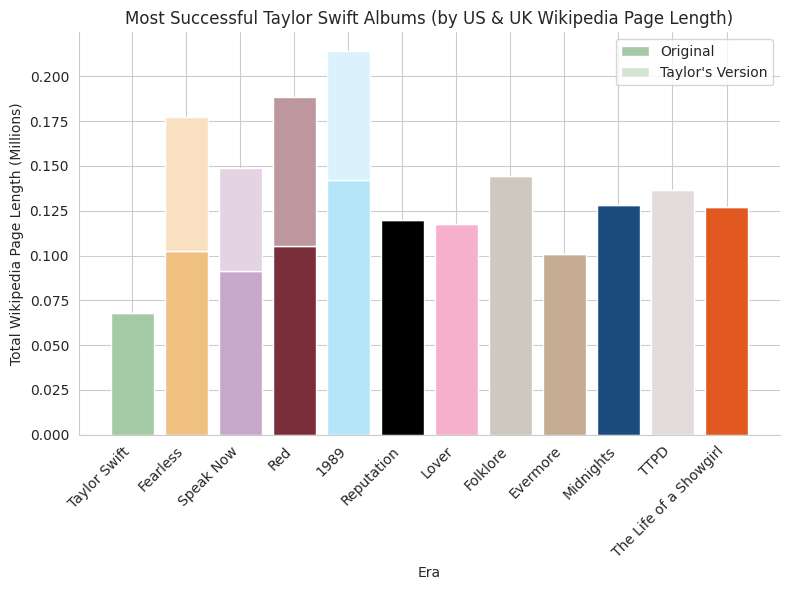

In [ ]:
plot_album_commercial_success("riaa_units", "bpi_units", "Total Units", "total_units") # plot charts showing certification units of albums
plot_album_commercial_success("us_sales", "uk_sales", "Total Sales", "total_sales") # plot charts showing sales of albums
plot_album_commercial_success("page_length", "0", "Wikipedia Page Length", "page_length") # plot charts showing sales of albums

In [ ]:
def plot_category_counts(column, table, title, figure_name): # plot counts of a categorical variable

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve the relevant column from the chosen table
  data = pd.read_sql(f"""
  SELECT {column}
  FROM {table}
  """, conn)

  # count how many observations fall into each category
  counts = data[column].value_counts()

  plt.figure(figsize = (8, 6)) # create a bar chart

  plt.bar(counts.index, counts.values, color = "#f6b0cc") # plot number of observations in each category

  plt.xticks(rotation = 45, ha = "right") # rotate labels for readability

  # label chart axes and title
  plt.xlabel(column.replace("_", " ").title())
  plt.ylabel("Count")
  plt.title(title)

  # remove unnecessary borders
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.savefig(f"{project_path}/output/figures/category_counts/{figure_name}.png", dpi = 300, bbox_inches = "tight") # save figure to drive

  plt.tight_layout()
  plt.show() # display chart

  conn.close() # close database connection

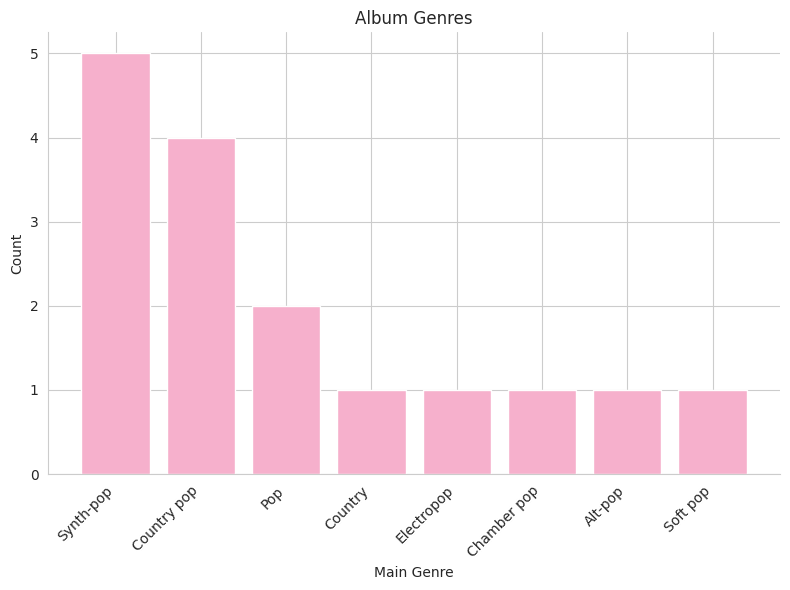

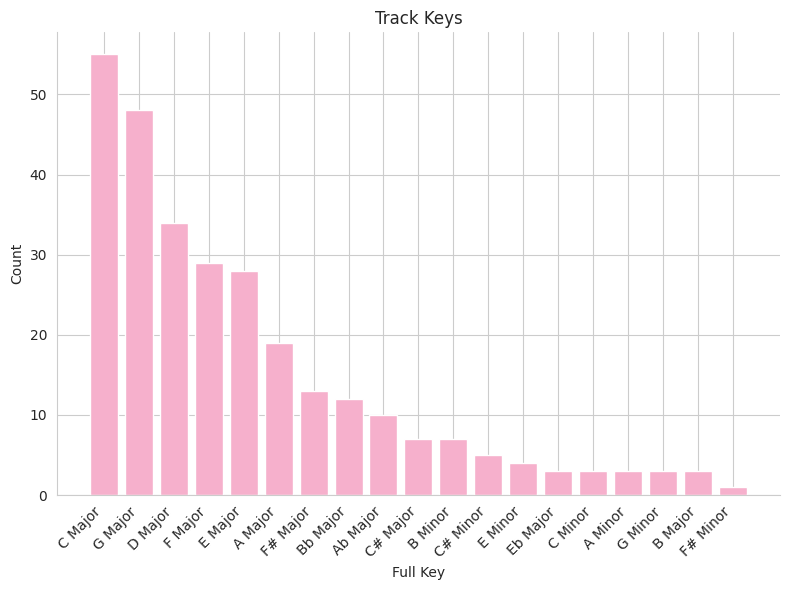

In [ ]:
plot_category_counts("main_genre", "albums", "Album Genres", "album_genres") # plot the genres
plot_category_counts("full_key", "tracks", "Track Keys", "track_keys") # plot the genres

In [ ]:
def plot_album_feature_success(feature, feature_name): # plot average album features against commercial success

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve album names, eras, total units and average of the chosen feature
  album_features = pd.read_sql(f"""
  SELECT t.album_id, a.album_name, a.era, (a.riaa_units + a.bpi_units) / 1000000 AS total_units, AVG(t.{feature}) AS avg_feature
  FROM tracks t
  JOIN albums a ON t.album_id = a.album_id
  WHERE a.album_name NOT LIKE '%(Taylor''s Version)%'
  GROUP BY t.album_id
  ORDER BY total_units ASC
  """, conn)

  album_features["era"] = album_features["era"].replace({"The Tortured Poets Department": "TTPD"}) # replace Tortured Poets with TTPD for readability

  sns.reset_defaults() # reset default formatting

  plt.figure(figsize = (10, 6)) # set figure size

  # plot a regression line for the average feature against album success
  sns.regplot(x = album_features["avg_feature"], y = album_features["total_units"], scatter = False, ci = None, line_kws = {"color": "grey", "linestyle": "--", "linewidth": 2})

  for era in album_features["era"].unique(): # for each era

    subset = album_features[album_features["era"] == era] # filter rows so each era can be plotted separately
    plt.scatter(subset["avg_feature"], subset["total_units"], color = era_colours.get(era, "#cccccc"), label = era) # plot each era with a consistent colour

  plt.xlabel(f"Average {feature_name}") # label x axis
  plt.ylabel("Total Units (Millions)") # label y axis
  plt.title(f"Average {feature_name} vs Commercial Success Across Eras") # label title

  plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left") # add a legend

  plt.gca().spines["top"].set_visible(False) # remove top line
  plt.gca().spines["right"].set_visible(False) # remove right line

  plt.savefig(f"{project_path}/output/figures/album_feature_success/album_{feature}_success.png", dpi = 300, bbox_inches = "tight") # save figure to drive

  plt.tight_layout() # use a tight layout
  plt.show() # show the graph

  conn.close() # close the connection

In [ ]:
# list of features
features = ["tempo", "energy", "danceability", "duration_min", "valence", "acousticness", "instrumentalness", "liveness", "loudness", "speechiness", "explicit"]
feature_names = ["Tempo", "Energy", "Danceability", "Duration in Minutes", "Valence", "Acousticness", "Instrumentalness", "Liveness", "Loudness", "Speechiness", "Explicitness"]

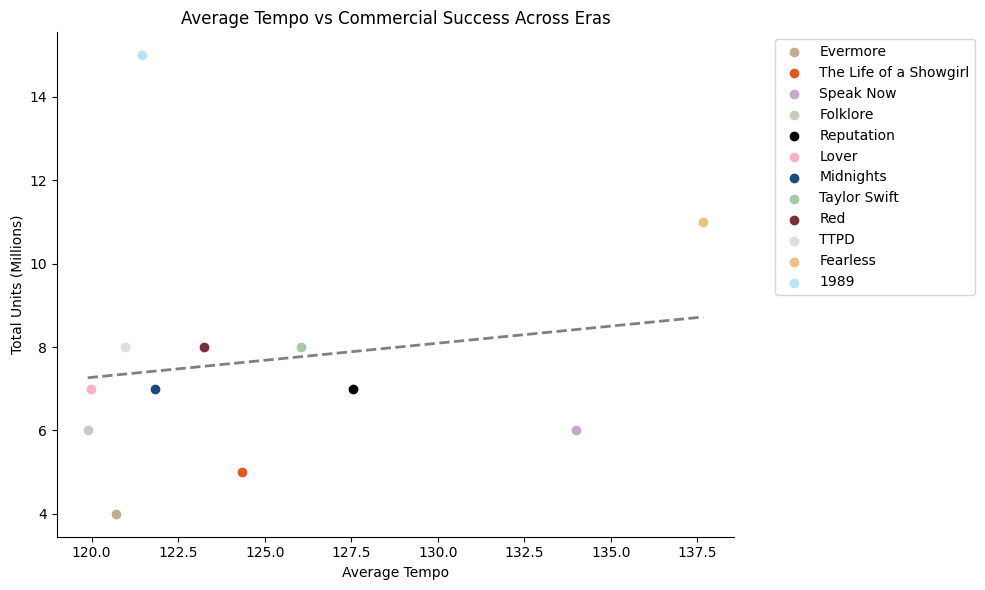

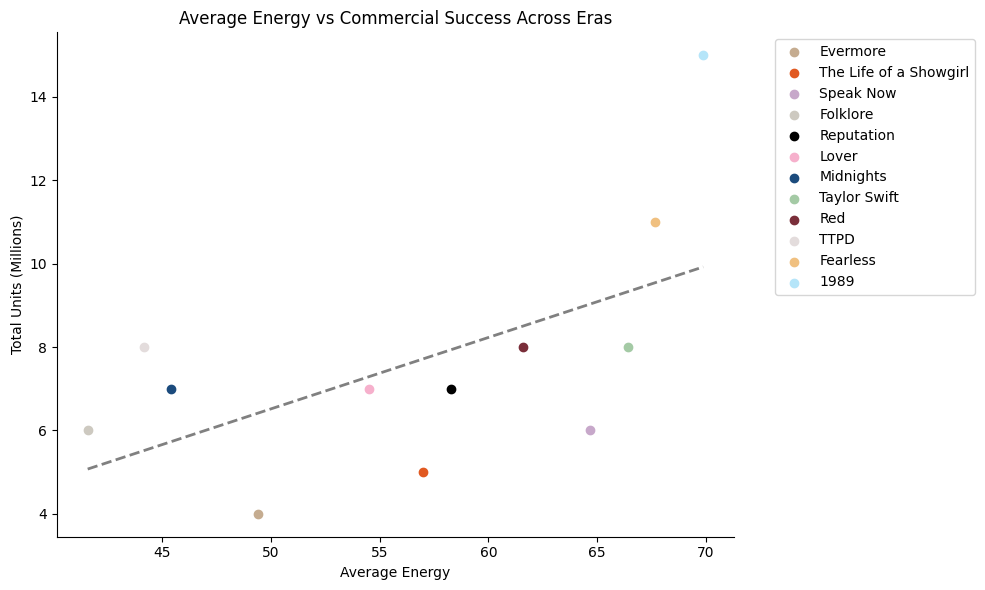

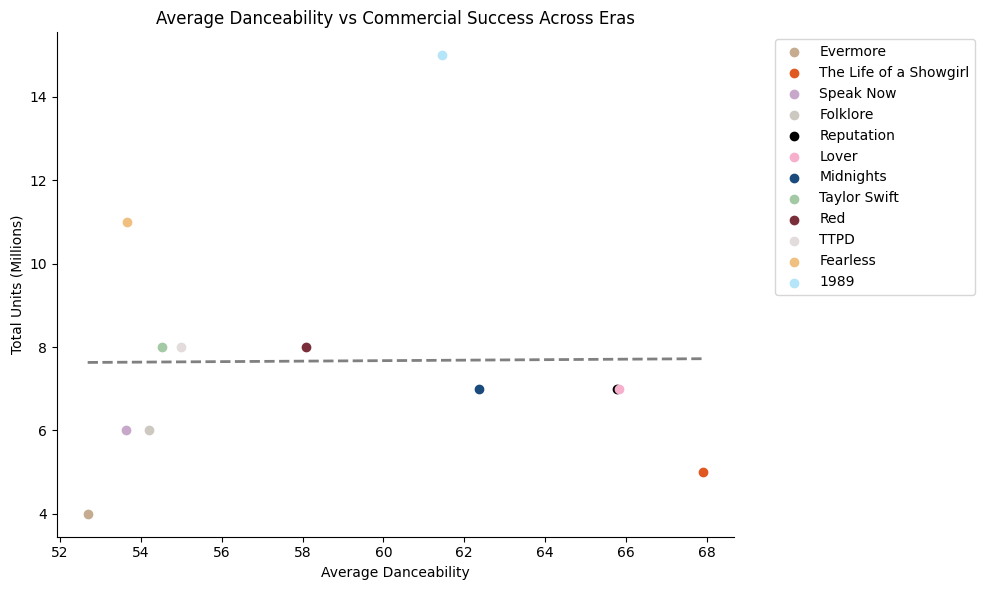

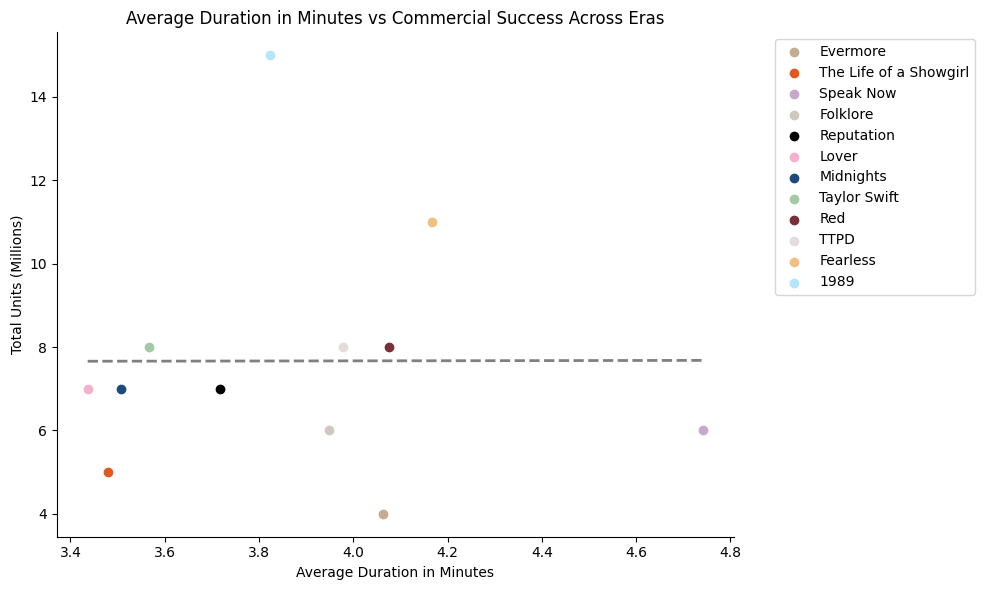

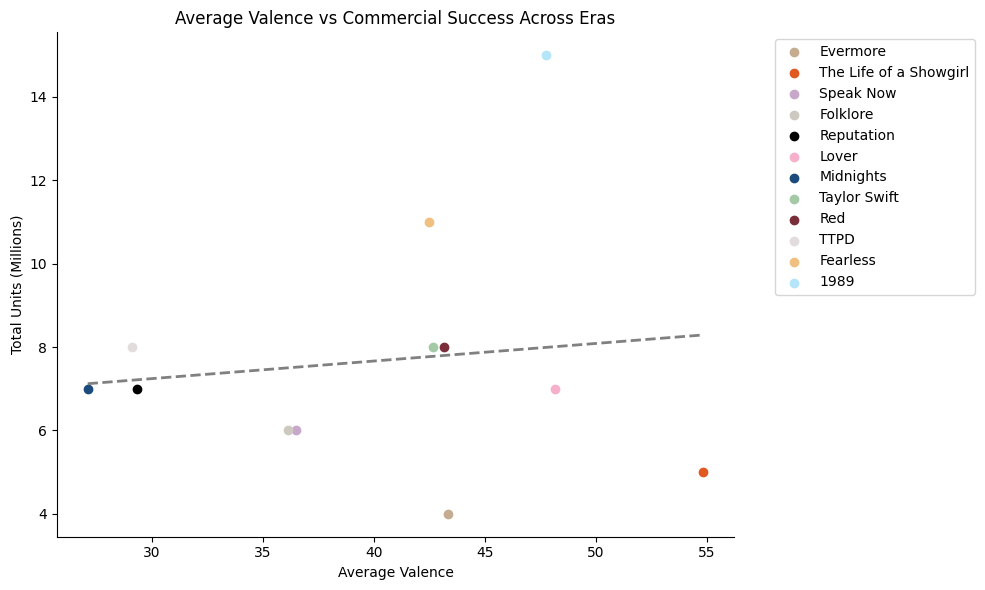

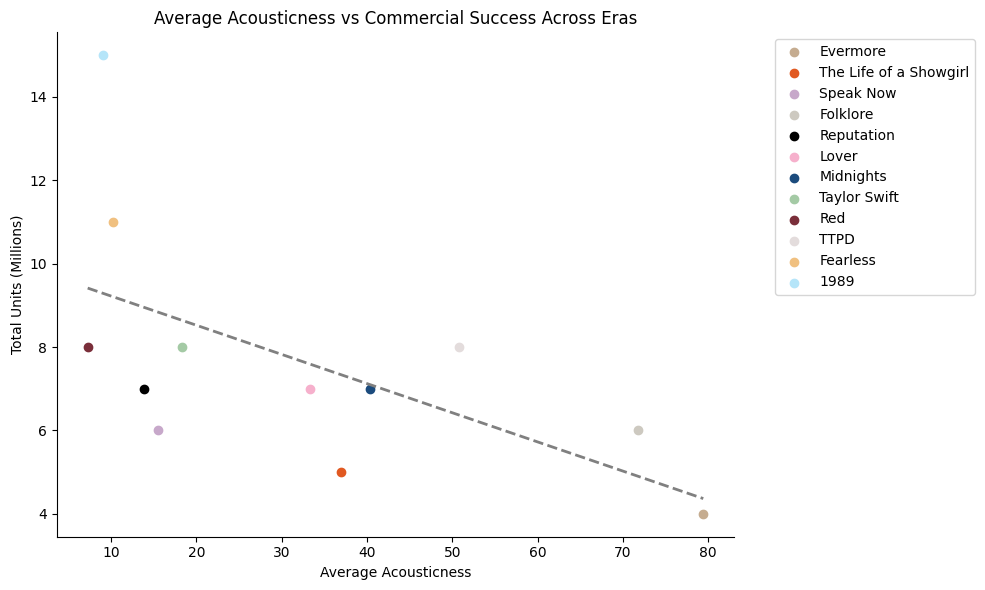

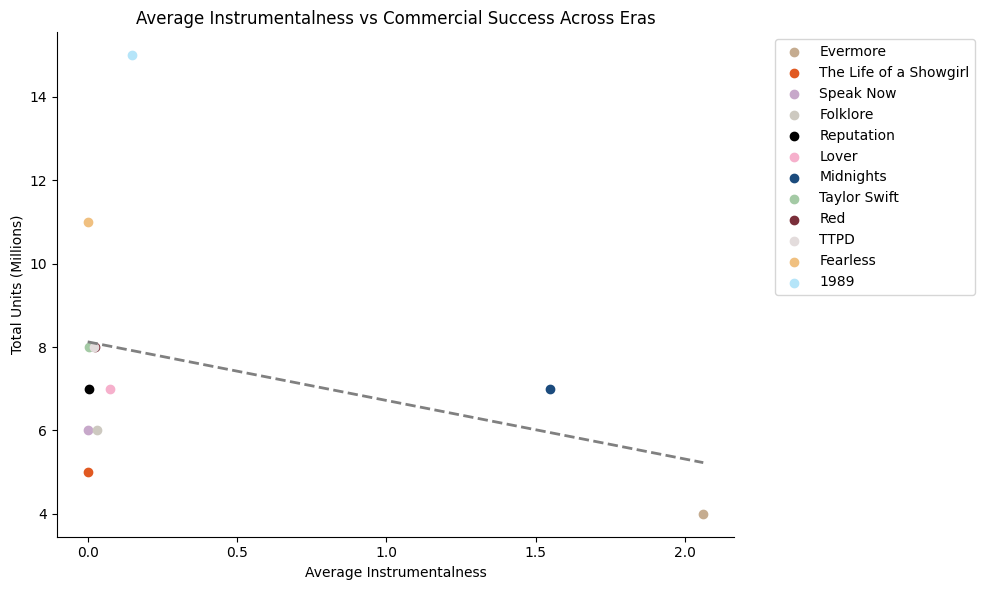

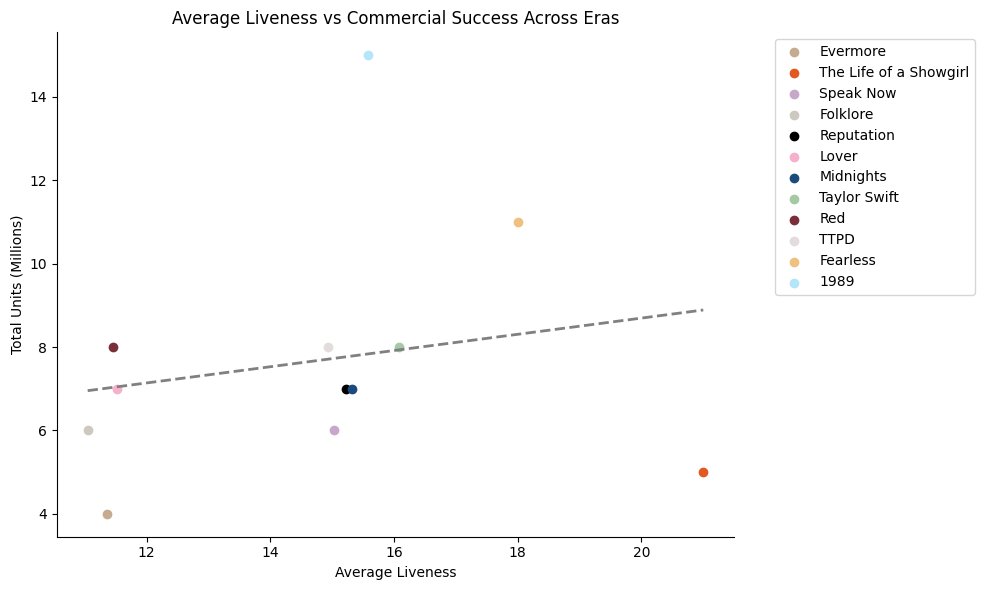

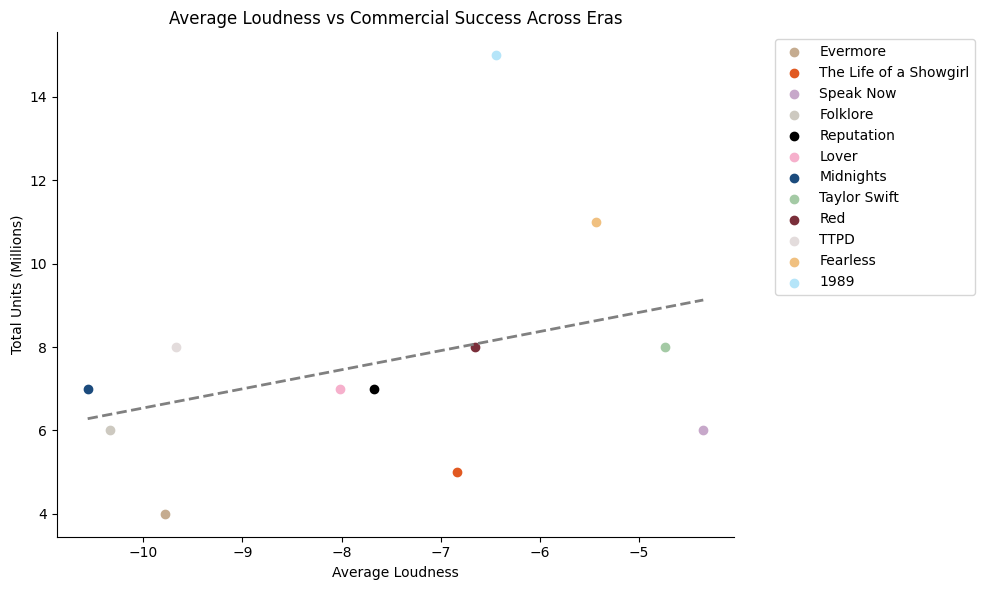

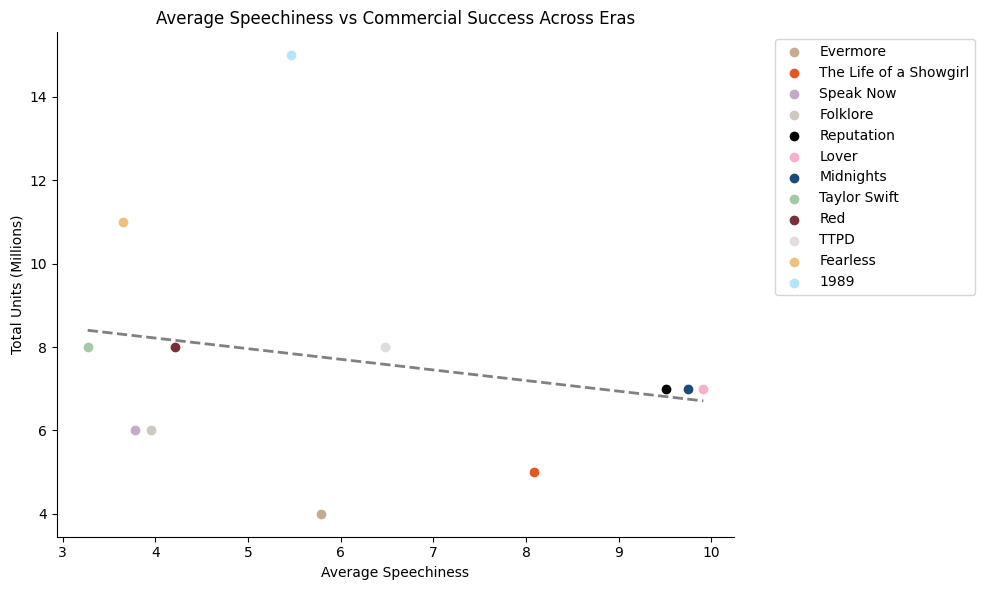

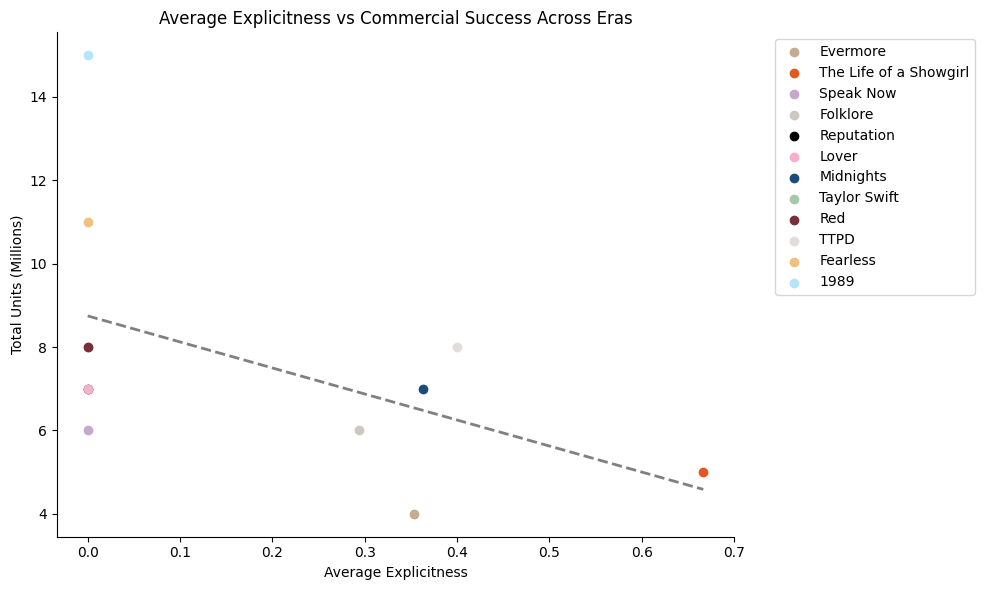

In [ ]:
for i in range(0, len(features)): # for each feature
  plot_album_feature_success(features[i], feature_names[i]) # plot each feature

In [ ]:
def plot_feature_time(feature, feature_name): # plot how average album features change across eras

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve album names, eras and average of the chosen feature
  album_features = pd.read_sql(f"""
  SELECT t.album_id, a.album_name, a.era, AVG(t.{feature}) AS avg_feature
  FROM tracks t
  JOIN albums a ON t.album_id = a.album_id
  WHERE a.album_name NOT LIKE '%(Taylor''s Version)%'
  GROUP BY t.album_id
  ORDER BY a.release_date ASC
  """, conn)

  album_features["era"] = album_features["era"].replace({"The Tortured Poets Department": "TTPD"}) # replace Tortured Poets with TTPD for readability

  album_features["era"] = pd.Categorical(album_features["era"], categories = era_order, ordered = True) # order eras chronologically
  album_features = album_features.sort_values("era") # sort data by era order

  base_colours = album_features["era"].astype(str).map(era_colours).fillna("#cccccc") # assign colours to each era

  sns.reset_defaults() # reset default formatting

  plt.figure(figsize = (8, 6)) # set figure size

  plt.plot(album_features["era"], album_features["avg_feature"], color = "grey", linestyle = "--", linewidth = 2) # add a dashed line across eras
  plt.scatter(album_features["era"], album_features["avg_feature"], color = base_colours) # add coloured scatter points

  for i, row in album_features.iterrows(): # for each row in the dataframe
    plt.text(row["era"], row["avg_feature"], f"{row['avg_feature']:.2f}", fontsize = 8, ha = "center", va = "bottom") # add labels above points

  plt.xticks(rotation = 45, ha = "right") # rotate labels so they do not overlap
  plt.xlabel("Era") # label x axis
  plt.ylabel(f"Average {feature_name}") # label y axis
  plt.title(f"Average {feature_name} Across Taylor Swift Eras") # label title

  plt.gca().spines["top"].set_visible(False) # remove top line
  plt.gca().spines["right"].set_visible(False) # remove right line

  plt.savefig(f"{project_path}/output/figures/album_feature_time/album_{feature}_time.png", dpi = 300, bbox_inches = "tight") # save figure to drive

  plt.tight_layout() # use a tight layout
  plt.show() # show the graph

  conn.close() # close the connection

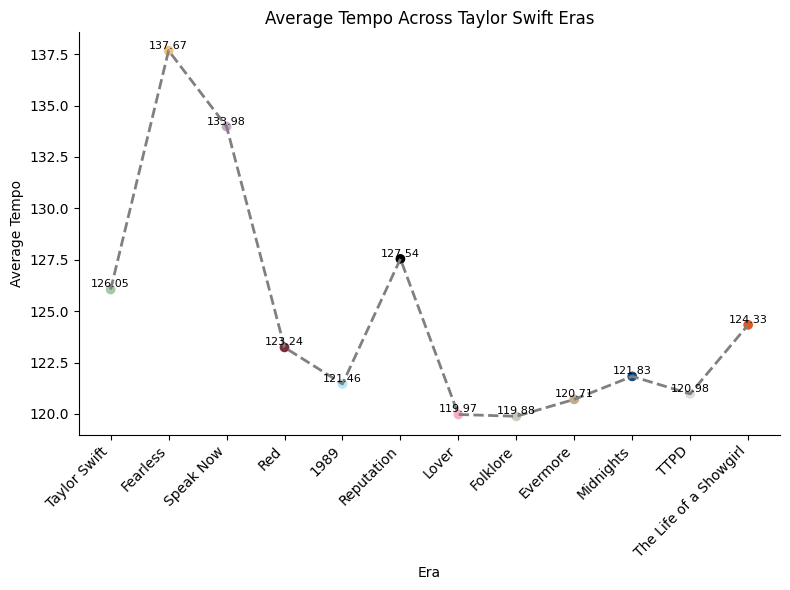

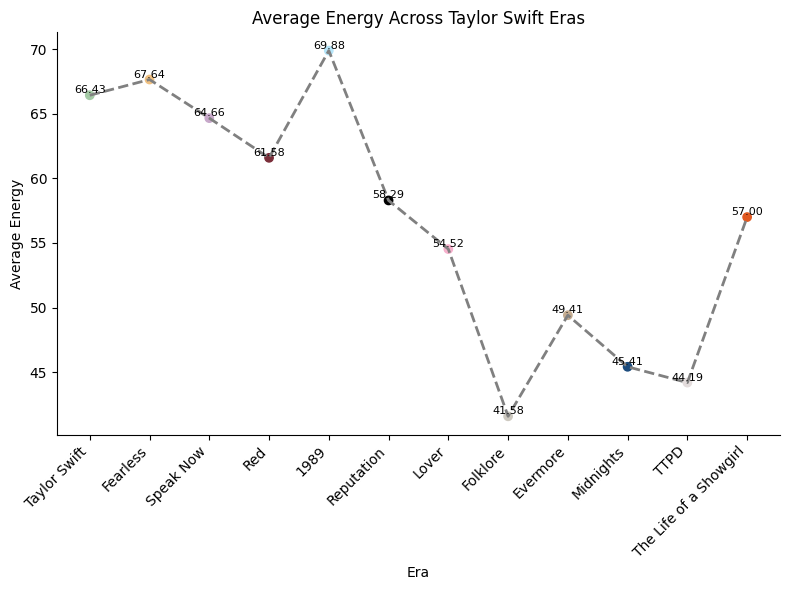

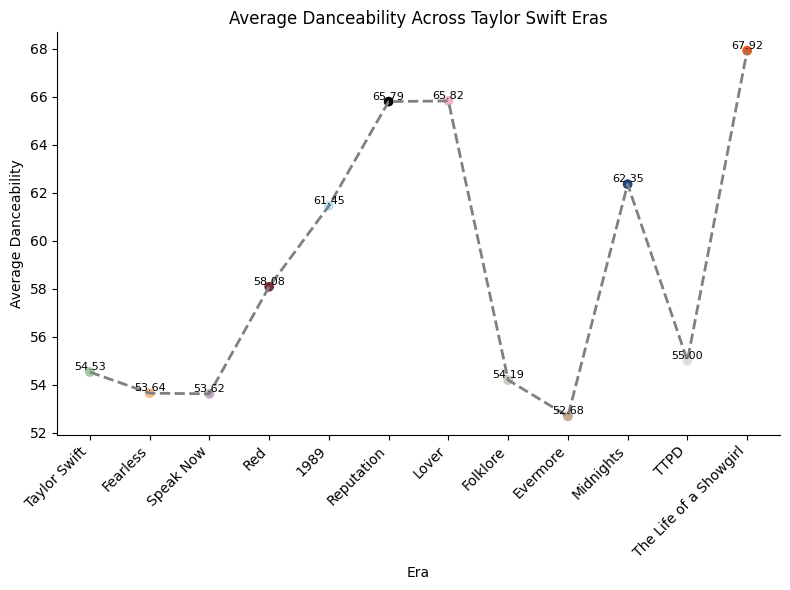

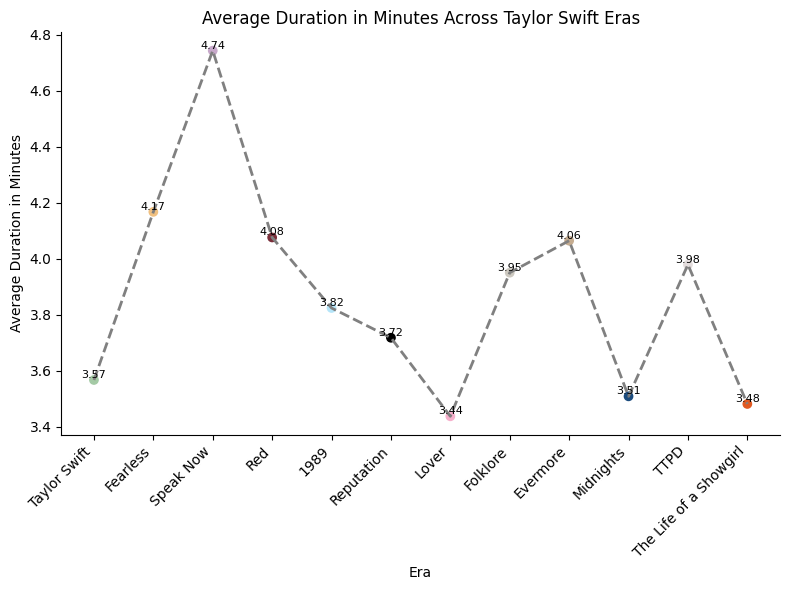

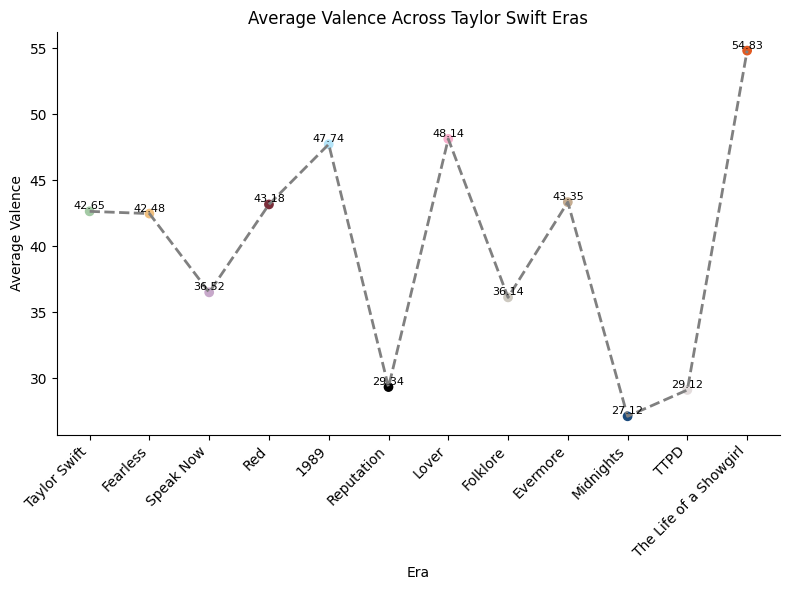

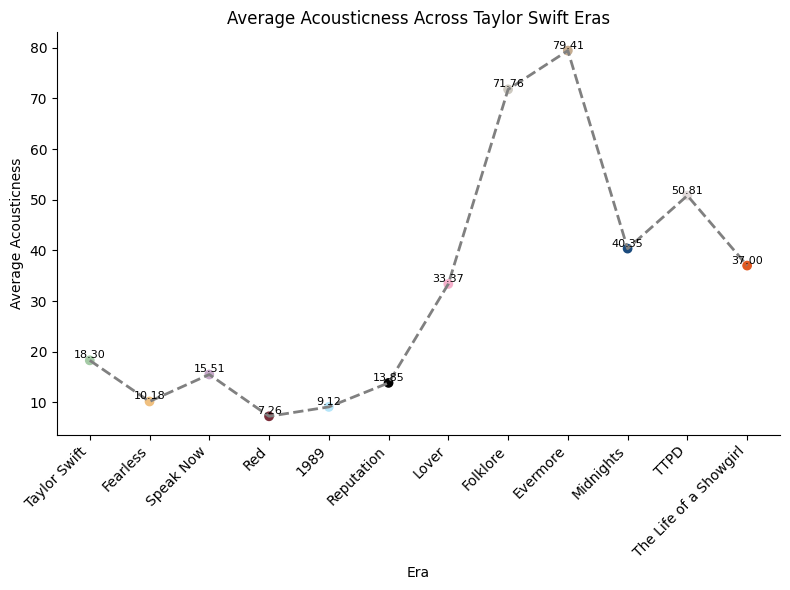

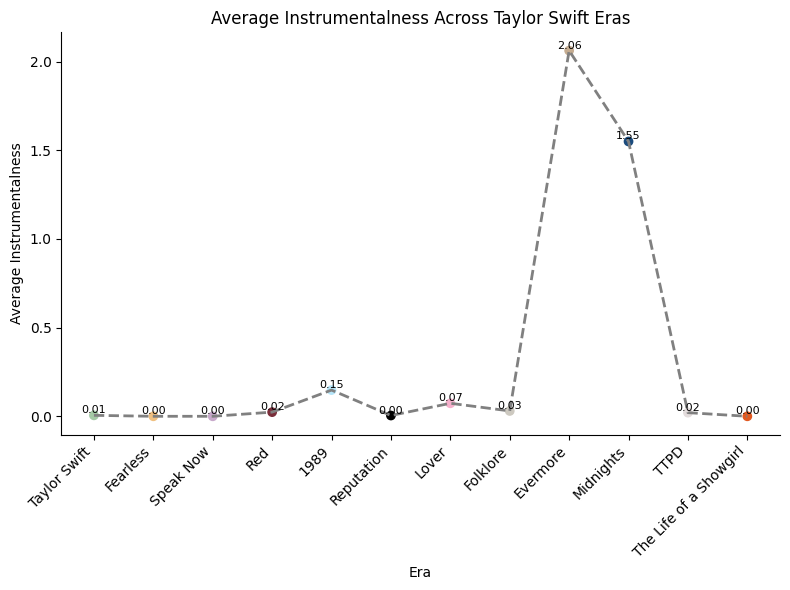

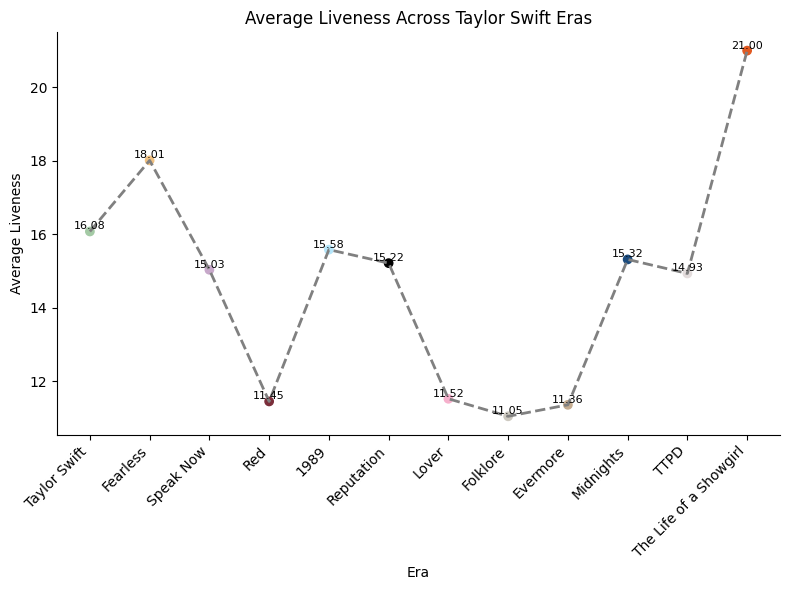

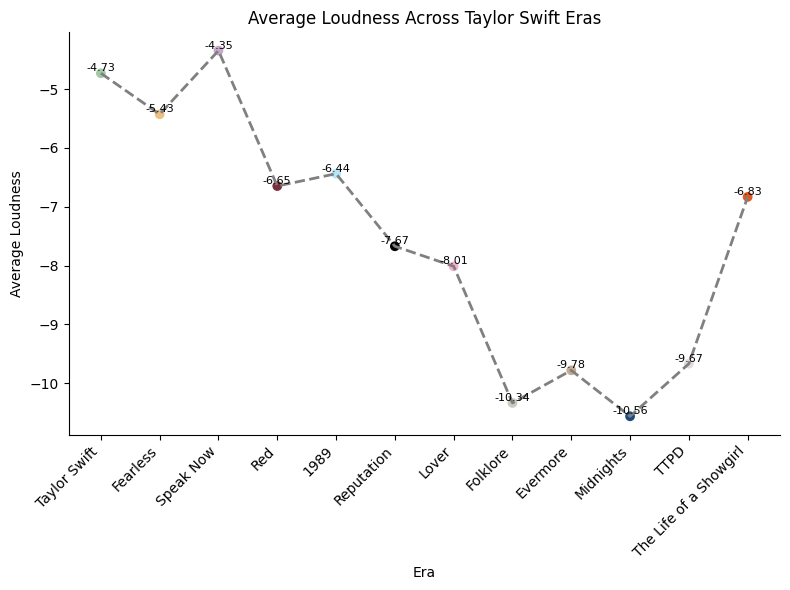

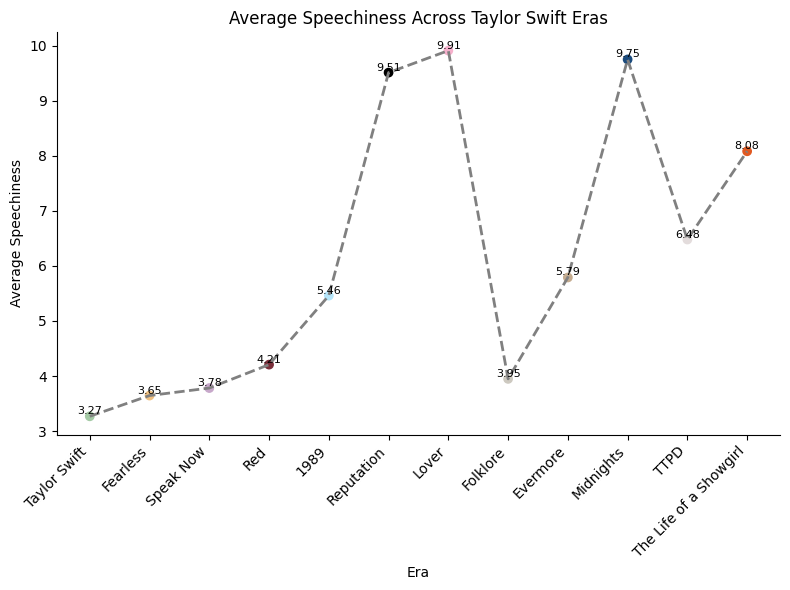

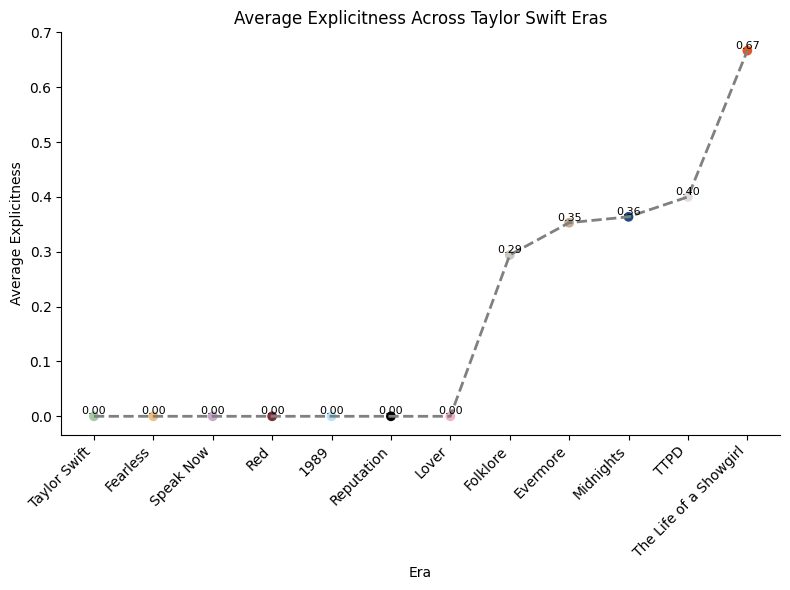

In [ ]:
for i in range(0, len(features)): # for each feature
  plot_feature_time(features[i], feature_names[i]) # plot each feature

In [ ]:
import numpy as np # library for numerical operations

In [ ]:
def plot_track_feature_success(feature, feature_name): # plot track features against track success using log listeners

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve track names, eras, feature values and listener counts
  track_features = pd.read_sql(f"""
  SELECT t.track_id, t.track_name, a.era, t.{feature} AS feature_value, t.listeners
  FROM tracks t
  JOIN albums a ON t.album_id = a.album_id
  WHERE t.listeners IS NOT NULL
  """, conn)

  track_features["era"] = track_features["era"].replace({"The Tortured Poets Department": "TTPD"}) # replace Tortured Poets with TTPD for readability

  # take the log of listeners so very large songs do not dominate the scale
  track_features["log_listeners"] = np.log(track_features["listeners"])

  sns.reset_defaults() # reset default formatting

  plt.figure(figsize = (10, 6)) # set figure size

  # plot a regression line for the feature against track success
  sns.regplot(x = track_features["feature_value"], y = track_features["log_listeners"], scatter = False, ci = None, line_kws = {"color": "grey", "linestyle": "--", "linewidth": 2})

  for era in track_features["era"].unique(): # for each era

    subset = track_features[track_features["era"] == era] # filter rows so each era can be plotted separately
    plt.scatter(subset["feature_value"], subset["log_listeners"], color = era_colours.get(era, "#cccccc"), label = era) # plot each era with a consistent colour

  plt.xlabel(f"{feature_name}") # label x axis
  plt.ylabel("Log Listeners") # label y axis
  plt.title(f"{feature_name} vs Track Success Across Eras") # label title

  plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left") # add a legend

  plt.gca().spines["top"].set_visible(False) # remove top line
  plt.gca().spines["right"].set_visible(False) # remove right line

  plt.savefig(f"{project_path}/output/figures/track_feature_success/track_{feature_name}_success.png", dpi = 300, bbox_inches = "tight") # save figure to drive

  plt.tight_layout() # use a tight layout
  plt.show() # show the graph

  conn.close() # close the connection

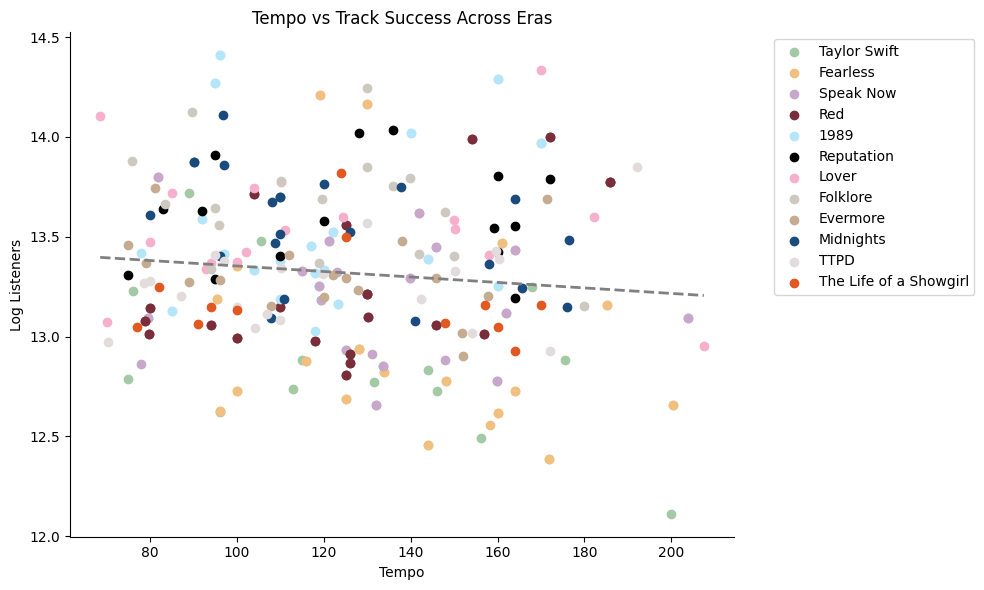

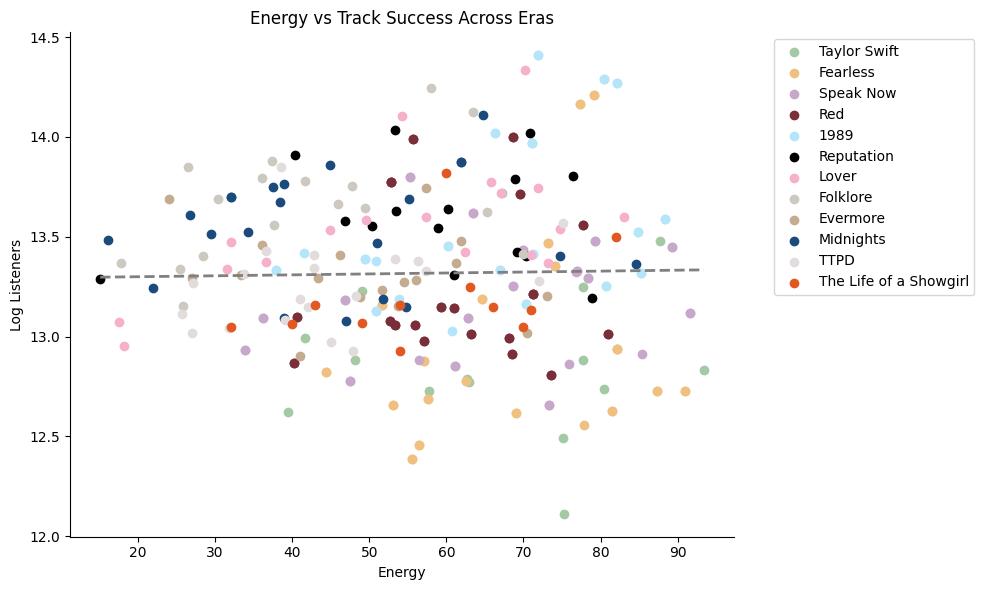

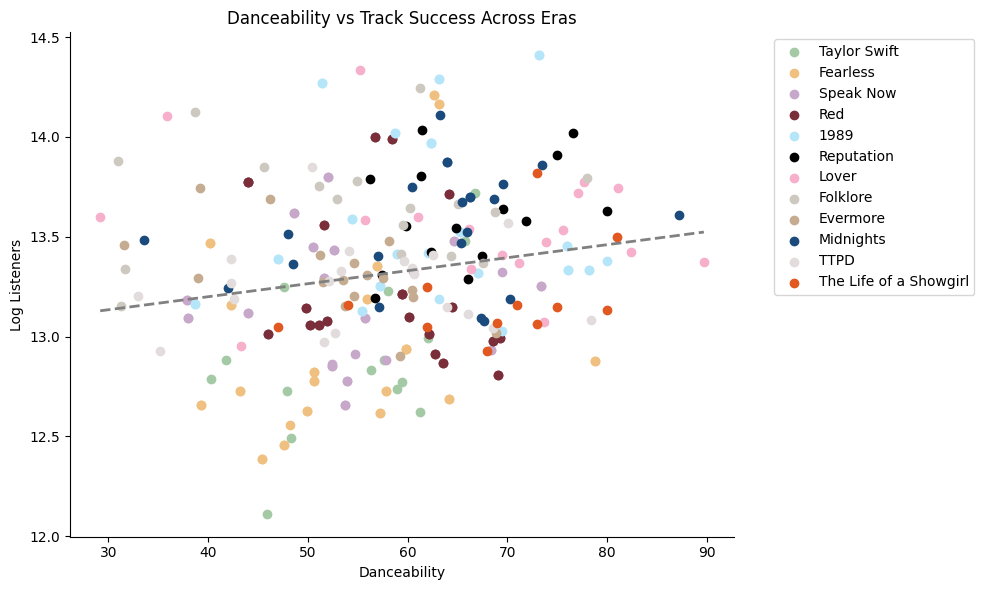

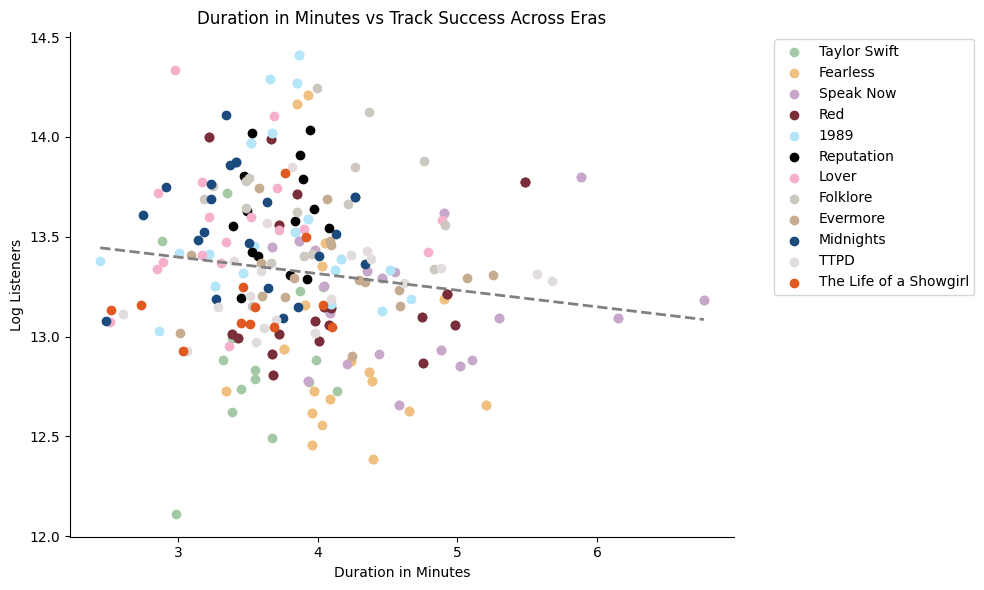

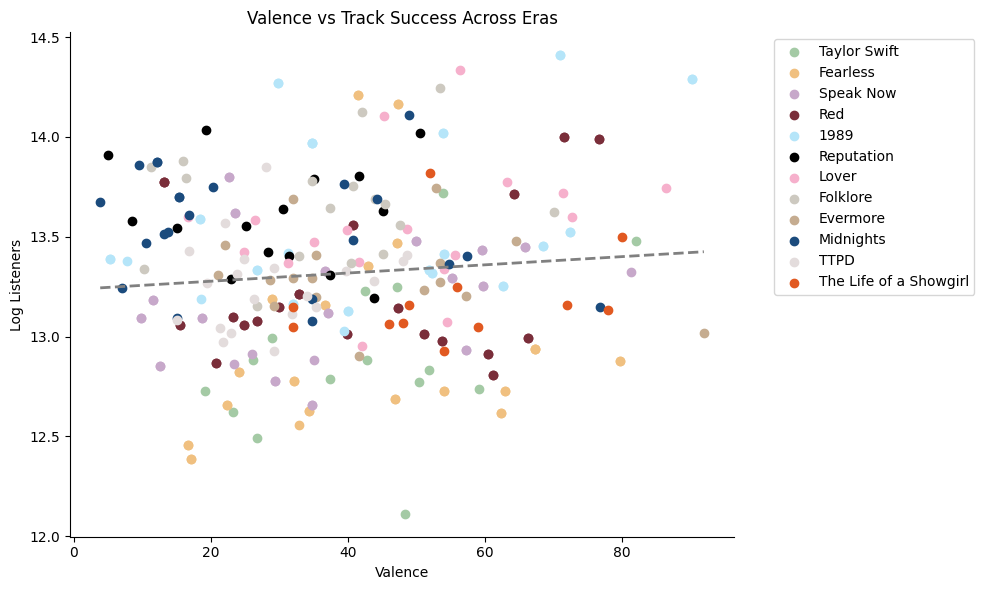

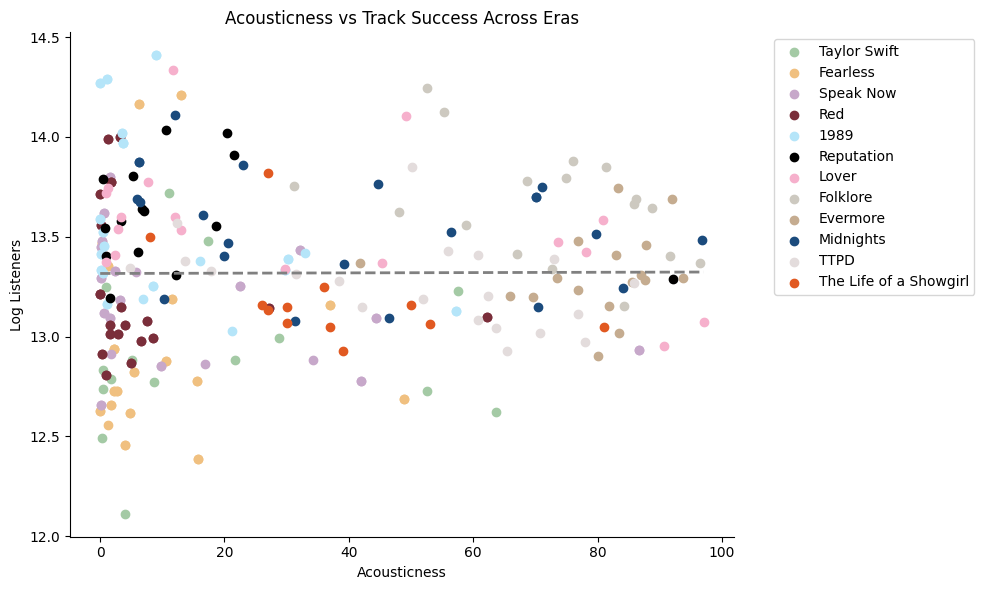

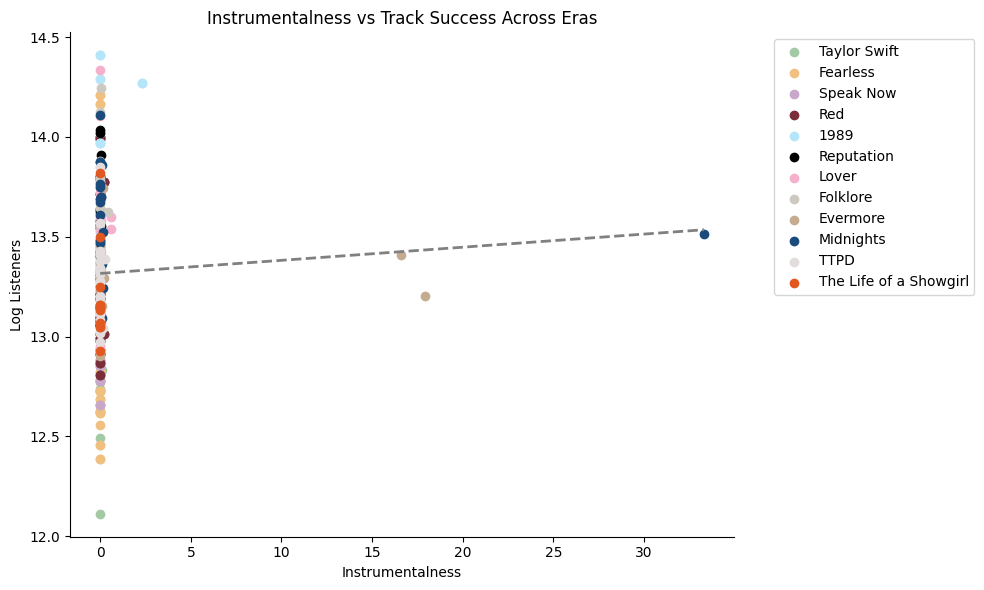

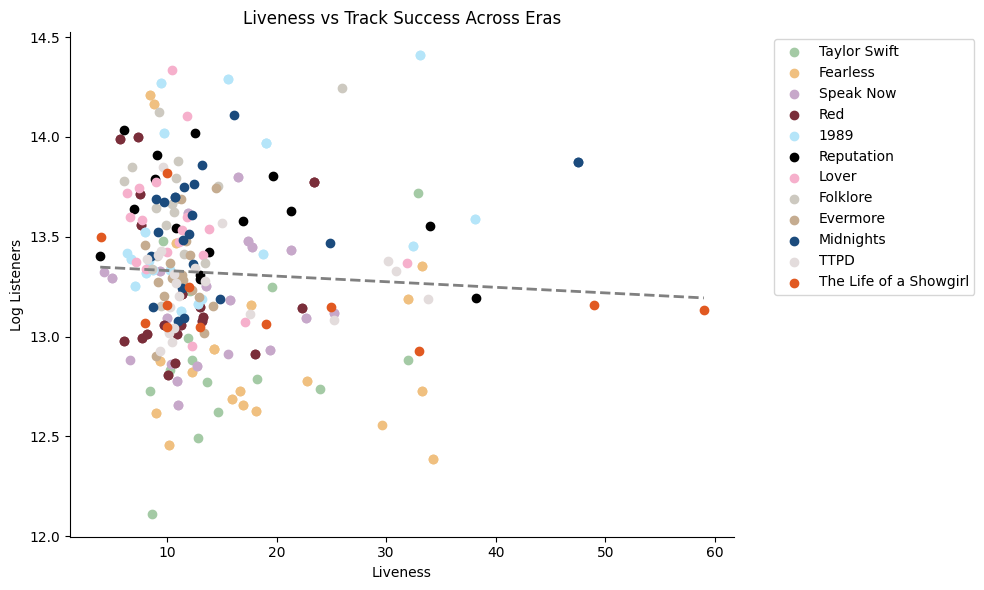

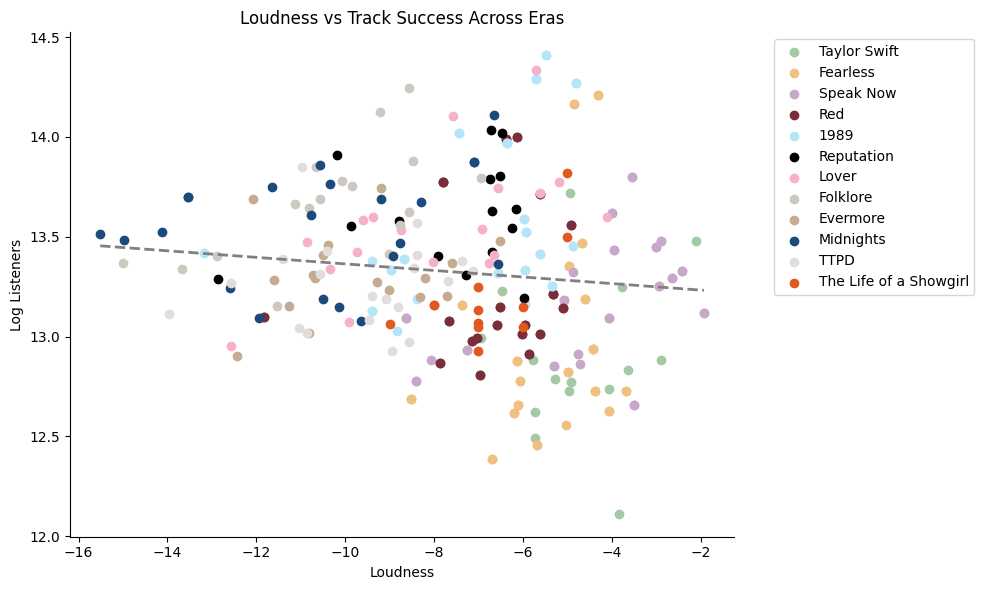

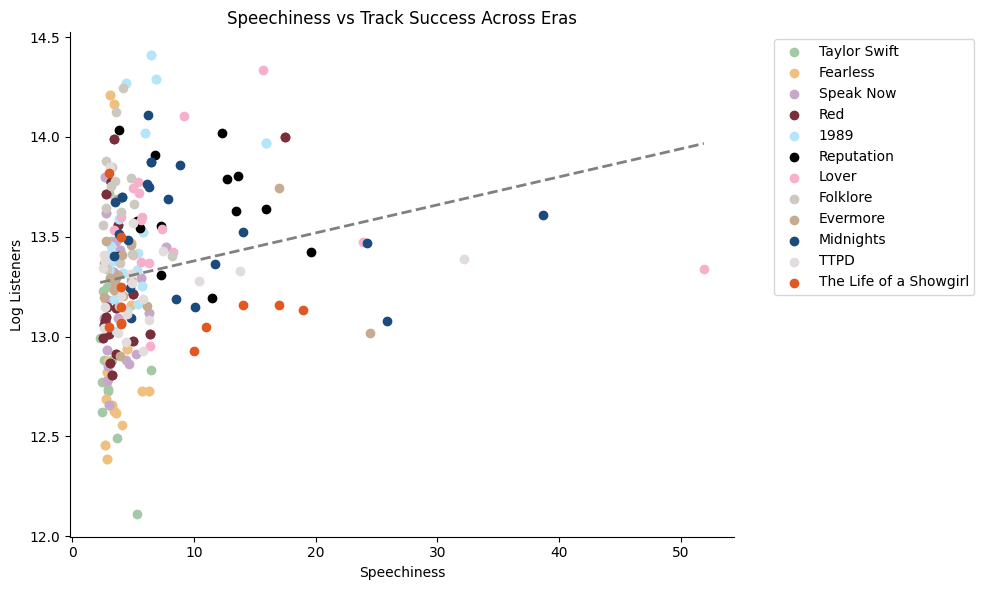

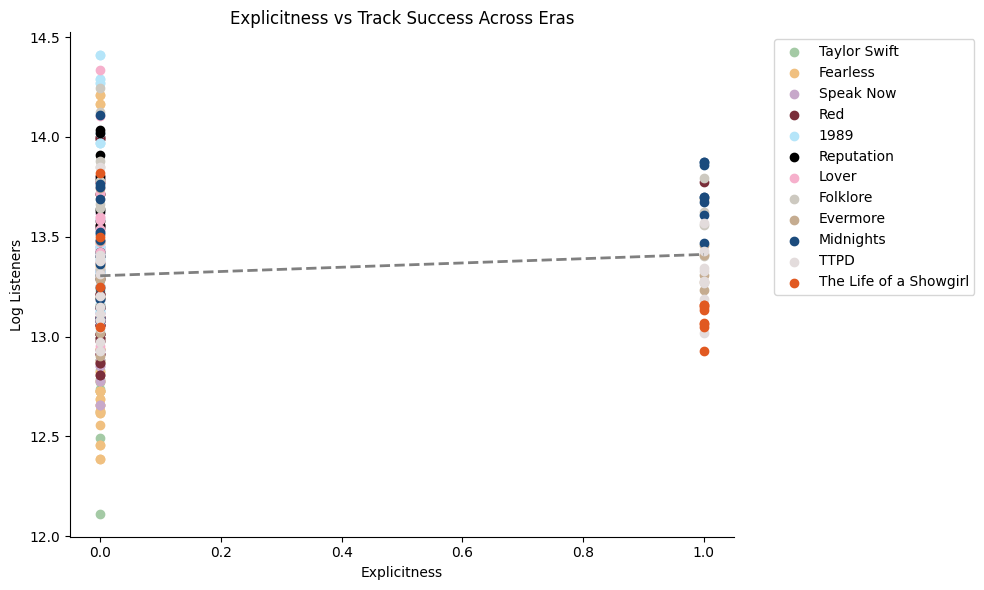

In [ ]:
for i in range(0, len(features)): # for each feature
  plot_track_feature_success(features[i], feature_names[i]) # plot each feature

In [ ]:
def plot_track_feature_time(feature, feature_name): # plot how track features change across eras

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve track names, eras and values of the chosen feature
  track_features = pd.read_sql(f"""
  SELECT t.track_id, t.track_name, a.era, t.{feature} AS feature_value
  FROM tracks t
  JOIN albums a ON t.album_id = a.album_id
  WHERE a.album_name NOT LIKE '%(Taylor''s Version)%'
  ORDER BY a.release_date ASC
  """, conn)

  track_features["era"] = track_features["era"].replace({"The Tortured Poets Department": "TTPD"}) # replace Tortured Poets with TTPD for readability

  track_features["era"] = pd.Categorical(track_features["era"], categories = era_order, ordered = True) # order eras chronologically
  track_features = track_features.sort_values("era") # sort data by era order

  base_colours = track_features["era"].astype(str).map(era_colours).fillna("#cccccc") # assign colours to each era

  sns.reset_defaults() # reset default formatting

  plt.figure(figsize = (8, 6)) # set figure size

  plt.scatter(track_features["era"], track_features["feature_value"], color = base_colours) # add coloured scatter points for each track

  plt.xticks(rotation = 45, ha = "right") # rotate labels so they do not overlap
  plt.xlabel("Era") # label x axis
  plt.ylabel(f"{feature_name}") # label y axis
  plt.title(f"{feature_name} Across Taylor Swift Eras") # label title

  plt.gca().spines["top"].set_visible(False) # remove top line
  plt.gca().spines["right"].set_visible(False) # remove right line

  plt.savefig(f"{project_path}/output/figures/track_feature_time/track_{feature}_time.png", dpi = 300, bbox_inches = "tight") # save figure to drive

  plt.tight_layout() # use a tight layout
  plt.show() # show the graph

  conn.close() # close the connection

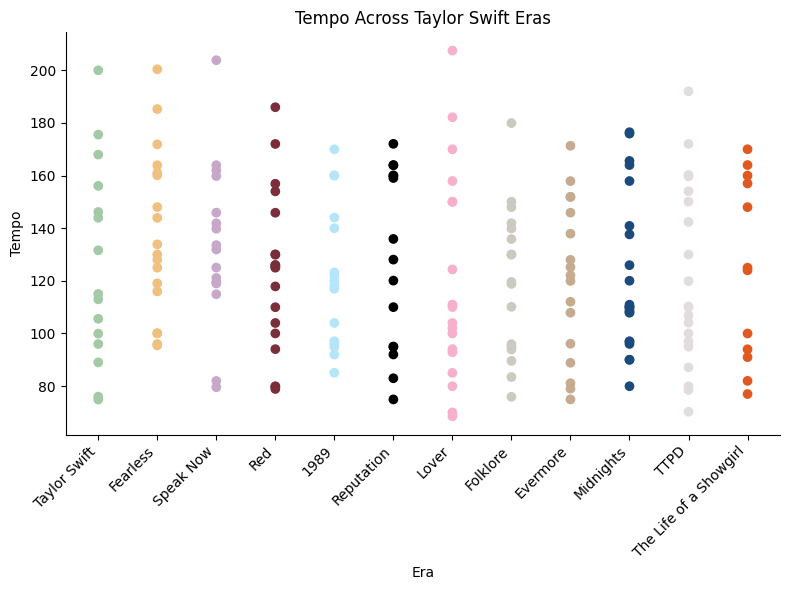

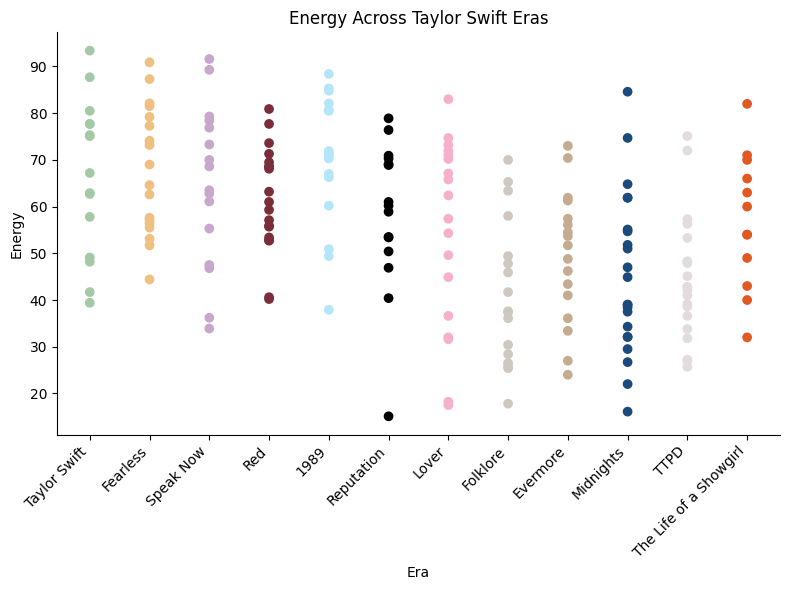

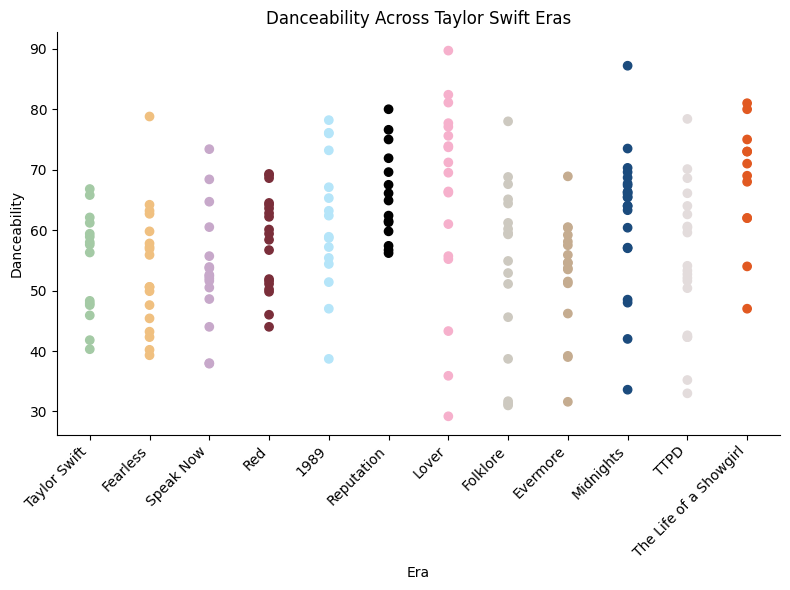

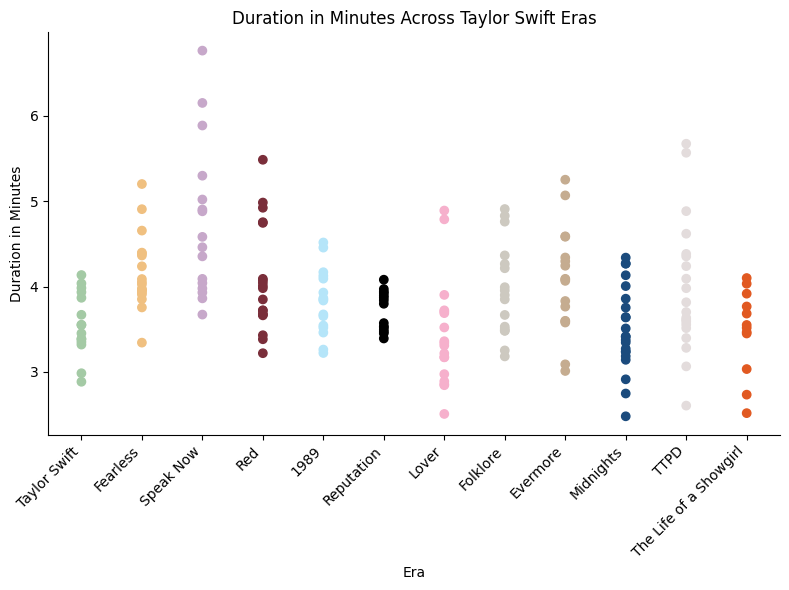

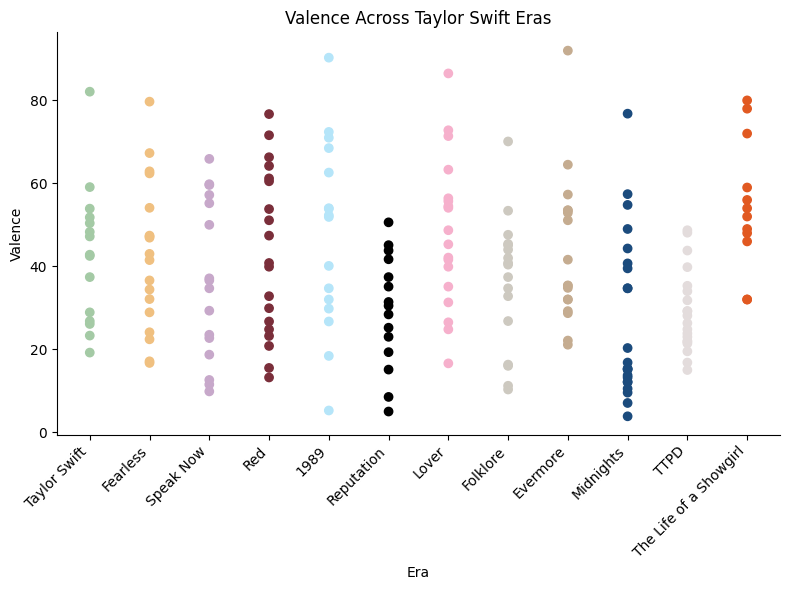

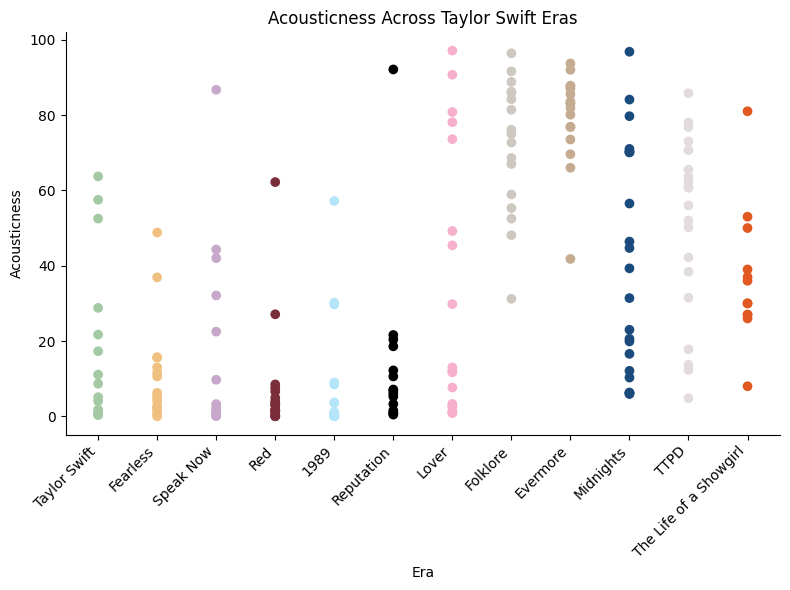

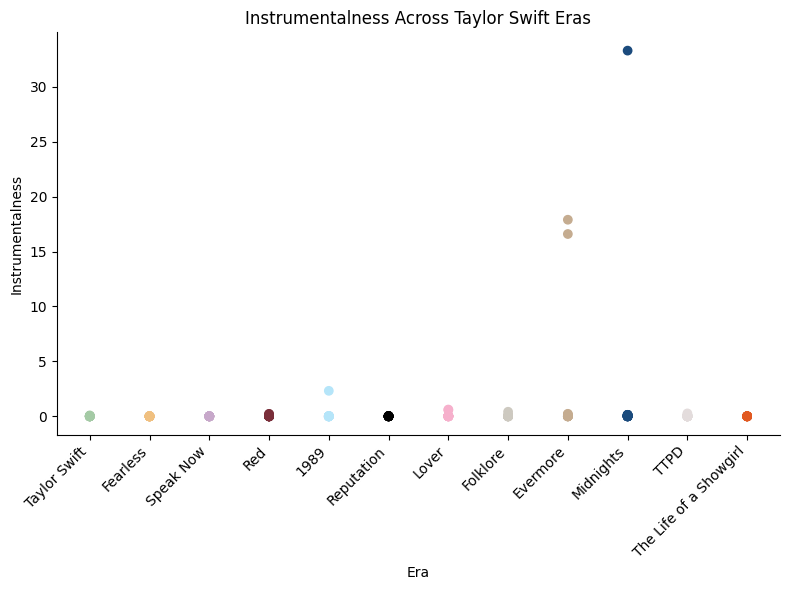

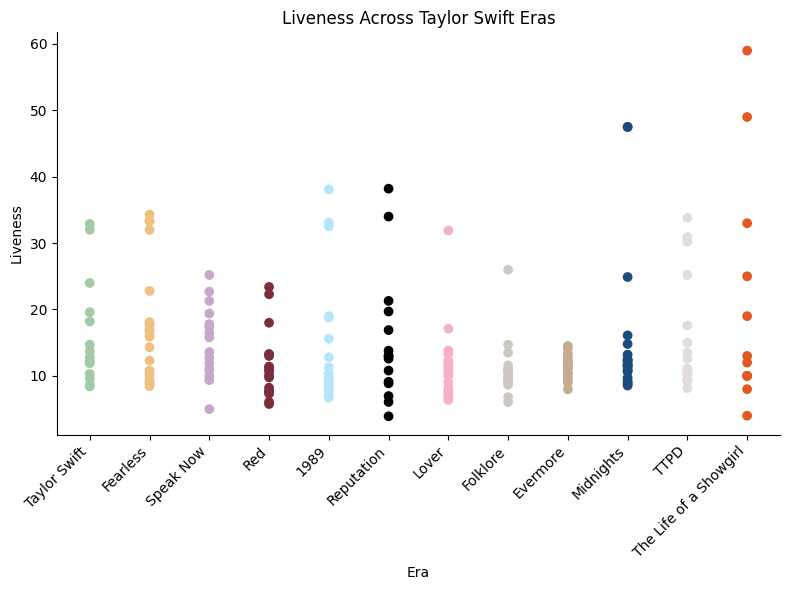

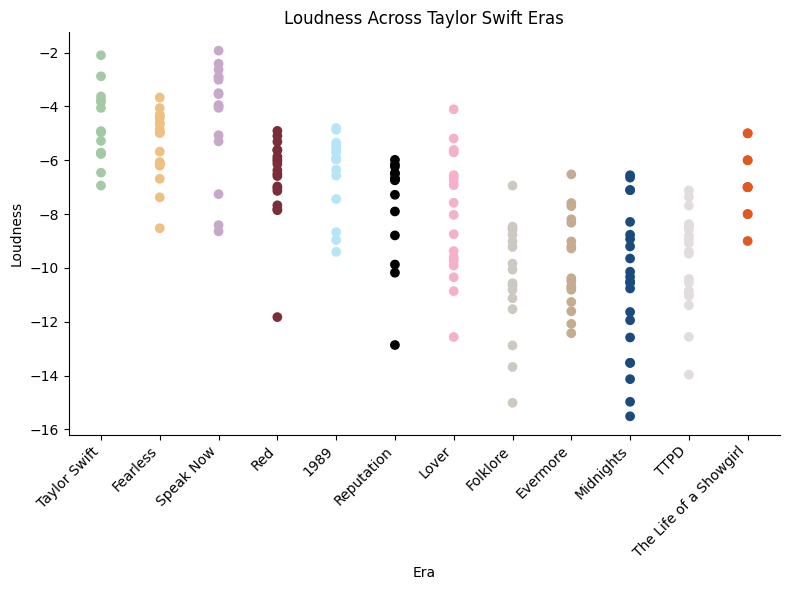

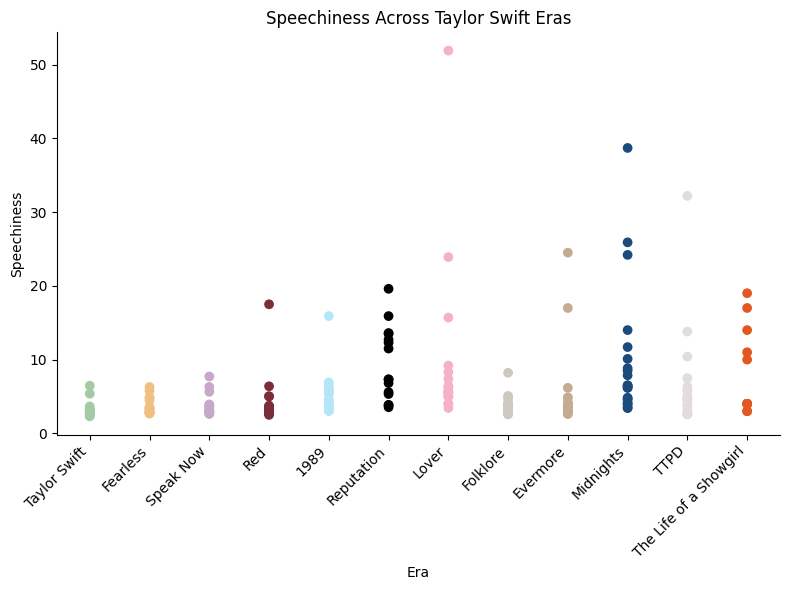

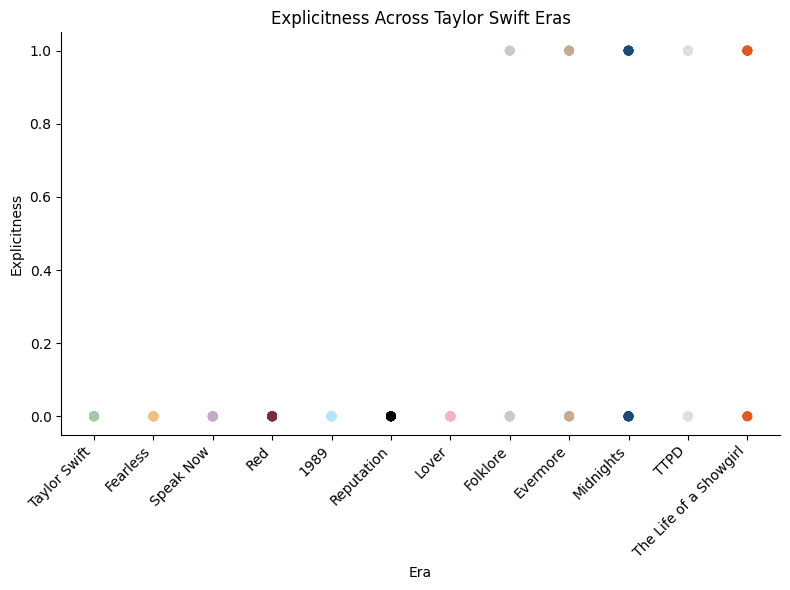

In [ ]:
for i in range(0, len(features)): # for each feature
  plot_track_feature_time(features[i], feature_names[i]) # plot each feature

In [ ]:
def plot_collaborations_success(figure_name): # plot number of collaborators against commercial success

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # calculate the number of unique collaborators per album and combine this with total certified units
  collabs = pd.read_sql("""
  SELECT a.album_id, a.album_name, a.era, COUNT(DISTINCT ta.artist_id) - 1 AS num_collaborators, (a.riaa_units + a.bpi_units) / 1000000 AS total_units
  FROM albums a
  JOIN tracks t ON a.album_id = t.album_id
  JOIN track_artists ta ON t.track_id = ta.track_id
  GROUP BY a.album_id, a.album_name, a.era
  ORDER BY total_units DESC
  """, conn)

  collabs["era"] = collabs["era"].replace({"The Tortured Poets Department": "TTPD"}) # replace Tortured Poets with TTPD for readability

  sns.reset_defaults() # use default formatting

  plt.figure(figsize = (10, 6)) # set figure size

  # add a line of best fit to show the overall relationship between collaborators and success
  sns.regplot(x = collabs["num_collaborators"], y = collabs["total_units"], ci = None, scatter = False, line_kws = {"color": "grey", "linestyle": "--"})

  for era in collabs["era"].unique(): # separate rows for each era so they can be plotted separately with labels
    subset = collabs[collabs["era"] == era]

    # plot era-specific points and use labels to create the legend
    plt.scatter(subset["num_collaborators"], subset["total_units"], color = era_colours.get(era, "#cccccc"), label = era)

  plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left") # place legend outside the plot area to keep the chart readable

  # label axes and title
  plt.xlabel("Number of Collaborators")
  plt.ylabel("Total Units (Millions)")
  plt.title("Number of Collaborators vs Commercial Success")

  # remove unnecessary borders for a cleaner visual style
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.savefig(f"{project_path}/output/figures/collaborations/{figure_name}.png", dpi = 300, bbox_inches = "tight") # save figure to drive

  plt.tight_layout()
  plt.show() # display chart

  conn.close() # close database connection

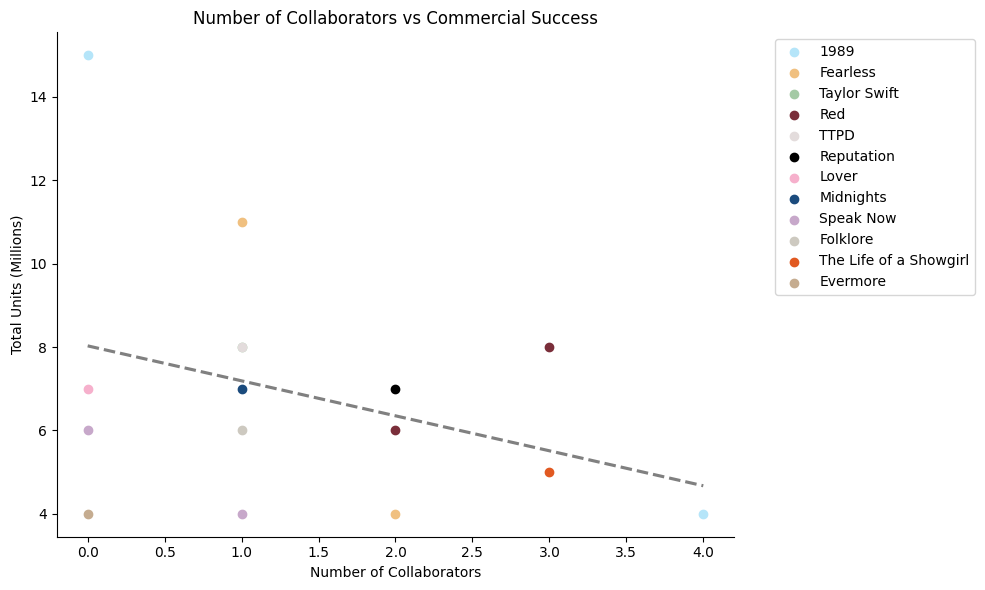

In [ ]:
plot_collaborations_success("number_of_collabs") # execute the function

In [ ]:
def plot_collaborator_popularity(figure_name): # plot collaborator popularity against commercial success

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # calculate the total collaborator listeners per album against album success
  collab_popularity = pd.read_sql("""
  SELECT a.album_id, a.album_name, a.era, SUM(art.listeners) / 1000000 AS total_collaborator_listeners, (a.riaa_units + a.bpi_units) / 1000000 AS total_units
  FROM albums a
  JOIN tracks t ON a.album_id = t.album_id
  JOIN track_artists ta ON t.track_id = ta.track_id
  JOIN artists art ON ta.artist_id = art.artist_id
  WHERE art.artist_name != 'Taylor Swift'
  GROUP BY a.album_id, a.album_name, a.era
  ORDER BY total_units DESC
  """, conn)

  # replace long era names for readability
  collab_popularity["era"] = collab_popularity["era"].replace({"The Tortured Poets Department": "TTPD"})

  sns.reset_defaults() # ensure default formatting

  plt.figure(figsize = (10, 6)) # set figure size

  # add a line of best fit to show the relationship between collaborator popularity and success
  sns.regplot(x = collab_popularity["total_collaborator_listeners"], y = collab_popularity["total_units"], ci = None, scatter = False, line_kws = {"color": "grey", "linestyle": "--"})

  for era in collab_popularity["era"].unique(): # for each unique era
    subset = collab_popularity[collab_popularity["era"] == era] # create a subset

    # plot era specific observations with consistent colours
    plt.scatter(subset["total_collaborator_listeners"], subset["total_units"], color = era_colours.get(era, "#cccccc"), label = era)

  plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left") # display legend outside of plot area

  # label axes and title
  plt.xlabel("Total Collaborator Listeners (Millions)")
  plt.ylabel("Total Units (Millions)")
  plt.title("Collaborator Popularity vs Commercial Success")

  # remove unnecessary borders
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.savefig(f"{project_path}/output/figures/collaborations/{figure_name}.png", dpi = 300, bbox_inches = "tight") # save figure to drive

  plt.tight_layout()
  plt.show() # show the graph

  conn.close() # close the connection

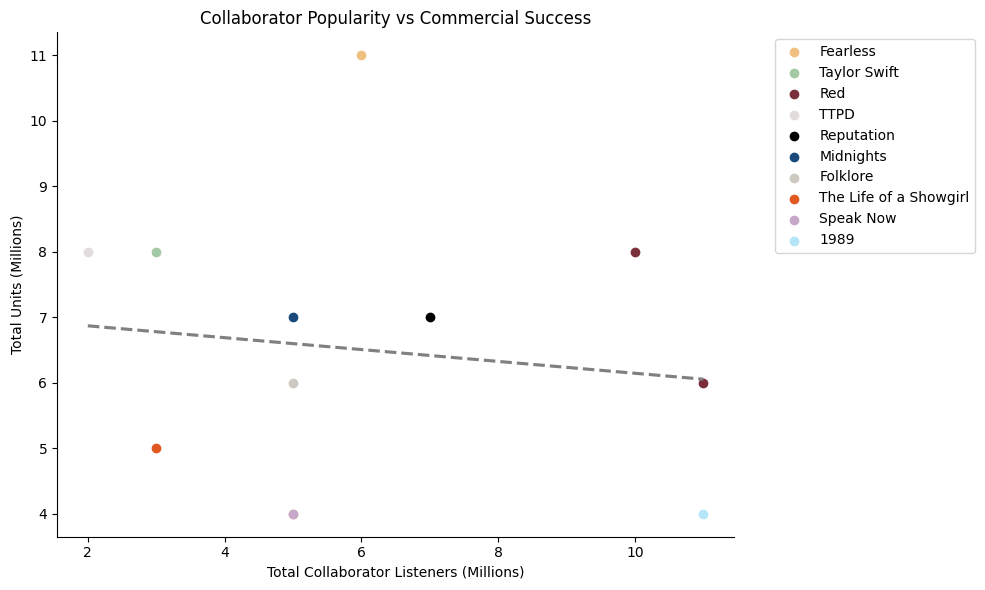

In [ ]:
plot_collaborator_popularity("popularity_of_collaborators")

In [41]:
conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # connect to database

# get track level data with features + listeners (our success measure)
track_data = pd.read_sql("""
SELECT t.track_id, t.track_name, a.album_name, a.era, t.listeners, t.tempo, t.energy, t.danceability, t.duration_min, t.valence, t.acousticness, t.instrumentalness, t.liveness, t.loudness, t.speechiness, t.explicit
FROM tracks t
JOIN albums a ON t.album_id = a.album_id
WHERE a.album_name NOT LIKE '%(Taylor''s Version)%'
""", conn)

conn.close() # close connection

In [43]:
# take log of listeners because raw values are very skewed (some songs are way bigger than others)
track_data["log_listeners"] = np.log(track_data["listeners"])

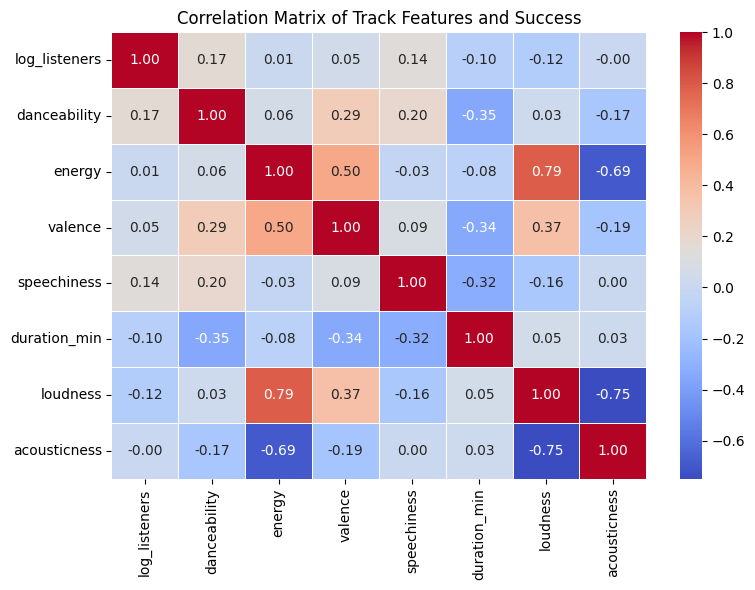

In [45]:
# select variables we want to check relationships between
corr_features = [
    "log_listeners",
    "danceability",
    "energy",
    "valence",
    "speechiness",
    "duration_min",
    "loudness",
    "acousticness"
]

# compute correlation matrix
corr_matrix = track_data[corr_features].corr()

# set up figure
plt.figure(figsize = (8, 6)) # make it big enough to read

# plot heatmap (pretty version of correlation matrix)
sns.heatmap(
    corr_matrix,
    annot = True,        # show numbers in each cell
    cmap = "coolwarm",   # blue = negative, red = positive
    fmt = ".2f",         # round to 2 decimal places
    linewidths = 0.5     # add lines between cells so it looks cleaner
)

plt.title("Correlation Matrix of Track Features and Success") # title

plt.tight_layout() # stops labels getting cut off
plt.show() # display plot

In [29]:
import statsmodels.api as sm

In [35]:
# select features that are decided before release and showed some relationship in graphs
features = ["danceability", "energy", "valence", "speechiness", "duration_min"]

X = track_data[features] # independent variables (features of the track)
y = track_data["log_listeners"] # dependent variable (track success)

X = sm.add_constant(X) # add constant term for intercept

model = sm.OLS(y, X).fit() # run OLS regression

print(model.summary()) # show results

                            OLS Regression Results                            
Dep. Variable:          log_listeners   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.718
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.132
Time:                        22:29:35   Log-Likelihood:                -100.37
No. Observations:                 205   AIC:                             212.7
Df Residuals:                     199   BIC:                             232.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           13.0562      0.294     44.381   

In [36]:
# add a couple more features that might matter but were less clear
features_extended = ["danceability", "energy", "valence", "speechiness", "duration_min", "loudness", "acousticness"]

X_ext = track_data[features_extended]
y = track_data["log_listeners"]

X_ext = sm.add_constant(X_ext)

model_ext = sm.OLS(y, X_ext).fit()

print(model_ext.summary())

                            OLS Regression Results                            
Dep. Variable:          log_listeners   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     2.373
Date:                Sat, 04 Apr 2026   Prob (F-statistic):             0.0238
Time:                        22:30:08   Log-Likelihood:                -96.399
No. Observations:                 205   AIC:                             208.8
Df Residuals:                     197   BIC:                             235.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.3666      0.399     30.996   

In [37]:
print("baseline R-squared:", model.rsquared)
print("extended R-squared:", model_ext.rsquared)

baseline R-squared: 0.04137633666123097
extended R-squared: 0.07777471086906107


In [38]:
# standardise features so coefficients are easier to compare
X_scaled = (track_data[features] - track_data[features].mean()) / track_data[features].std()
X_scaled = sm.add_constant(X_scaled)

model_scaled = sm.OLS(y, X_scaled).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:          log_listeners   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.718
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.132
Time:                        22:31:34   Log-Likelihood:                -100.37
No. Observations:                 205   AIC:                             212.7
Df Residuals:                     199   BIC:                             232.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           13.3481      0.028    476.932   